# Parametric Statistical Significance Tests



> *prepared with AI aid.*


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 1. Why Statistical Significance Tests?

In the **data science life cycle**, statistical significance tests are integrated across almost every phase to ensure that decisions are based on **reliable evidence** rather than random noise or chance.

<p style="color: steelblue; font-size: 1.5em;">Where are they used?</p>

**Data Preparation & Feature Engineering**

Statistical tests decide which variables (features) are worth including (i.e., have a significant impact on the target variable).

- **Chi-Square test** – to see if a categorical feature (like "Country") is related to the outcome.
- **ANOVA** – to see if different groups have significantly different target means.
- **Pearson Correlation test** – to see if two columns are highly correlated, then remove one of them.

**Data Understanding & Exploration (EDA)**

Statistical tests identify data distributions.

- **Normality Tests** (like Shapiro-Wilk) – to see if data follows a normal distribution.
- **Outlier Detection** (Z-scores) – to find statistically extreme values.
- Statistical tests to check if the data is "Missing at Random."

**Model Evaluation & Selection**

Statistical tests prove that Model A is better than Model B because of its architecture, not just because of a lucky data split.

- Using a **Paired T-test** on cross-validation results to compare the accuracy of two algorithms. If the p-value is > 0.05, the observed "better" performance of one model might just be a fluke.

**Model Deployment & Monitoring**

Statistical tests are used to detect **data drift**.

- Using a **Kolmogorov-Smirnov (K-S) test** to compare the distribution of incoming live data against the training set distribution. A significant difference triggers an alert to retrain the model.

**Post-Deployment**

Statistical tests measure the real-world impact of the model's predictions.

- Conducting **A/B Testing** or online experiments where users are randomly assigned to either the model-driven experience or a control group.

</div>



<div style="max-width: 1000px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 2. Core Concepts & Important Terms

<p style="color: steelblue; font-size: 1.5em;">Null & Alternative Hypotheses</p>

| Term | Definition |
|------|-----------|
| **Null hypothesis (H₀)** | *Nothing has changed.* There is no difference, no effect, no relationship. |
| **Alternative hypothesis (H₁)** | *Something has changed.* There is a difference, an effect, or a relationship. |

> **Intuition:** Think of H₀ as "innocent until proven guilty." We start by assuming nothing interesting is happening. We only conclude something *is* happening if the data provides strong enough evidence.

<p style="color: steelblue; font-size: 1.5em;">p-value</p>

The **p-value** tells you how likely it is to observe your results (or more extreme results) *if the null hypothesis were true*.

- **Small p-value** → the result is unlikely to be random → evidence against H₀.
- **Large p-value** → the result could easily occur by chance → no strong evidence against H₀.

> **Intuition:** Imagine flipping a coin 10 times and getting 10 heads. If the coin were fair (H₀), this is very unlikely (p = (1/2)¹⁰ = 1/1024 ≈ 0.001). That tiny probability is the p-value. It's NOT the probability that H₀ is true — it's the probability of seeing your data *if* H₀ were true.

**Common p-value misconceptions:**

- ❌ *"p = 0.04 means there's a 4% chance the null hypothesis is true."*
  ✅ Reality: p-value is the probability of observing data at least as extreme as ours, **given** H₀ is true.
- ❌ *"p = 0.04 is way better than p = 0.06."*
  ✅ Reality: The 0.05 threshold is **arbitrary**. Both suggest weak-to-moderate evidence. Don't treat 0.05 as a sharp dividing line.
- ❌ *"Non-significant results mean no effect."*
  ✅ Reality: Failure to reject H₀ doesn't prove H₀ is true. Maybe the sample size was too small to detect the effect.

<p style="color: steelblue; font-size: 1.5em;">Significance Level (α)</p>

**α (alpha)** is your **threshold** for deciding whether a p-value is "small enough" to reject H₀.

- Most commonly: **α = 0.05** (5%)
- If **p-value ≤ α** → **Reject H₀** (statistically significant)
- If **p-value > α** → **Fail to reject H₀** (not statistically significant)

> **Intuition:** α is the maximum probability of making a Type I Error (false alarm) you are willing to accept. Setting α = 0.05 means you accept a 5% risk of wrongly rejecting a true null hypothesis.

<p style="color: steelblue; font-size: 1.5em;">Sample Mean vs Population Mean</p>

| Term | Symbol | Meaning |
|------|--------|---------|
| **Population mean (true mean)** | μ (mu) | The precise average of **all** data points in the entire population |
| **Sample mean** | x̄ (x-bar) | The average of a smaller group (sample) taken from the population — an **estimate** of μ |

Since we rarely have access to the entire population, we work with samples and use the sample mean to estimate the population mean. This is why all hypothesis tests involve uncertainty.

</div>


**todo**


<div style="max-width: 900px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 3. Confidence Intervals

<p style="color: steelblue; font-size: 1.5em;">What is a Confidence Interval?</p>

A **confidence interval (CI)** provides a **range of values** that likely contains the true population parameter (e.g., the true mean). It gives you more depth than a p-value alone by showing the **uncertainty** around your estimate.

> A conversion rate improvement of **1.2%** with a **95% CI of [0.8%, 1.6%]** is far more useful than a simple p-value — it tells you both the direction and the plausible range of the true effect.

**Formula for the Confidence Interval (using t-distribution):**

```
CI = x̄ ± t_critical × SE
```

Where:
- `x̄` = sample mean
- `t_critical` = critical value from the t-distribution (depends on confidence level and df)
- `SE` = Standard Error = `s / √n`
- `s` = sample standard deviation
- `n` = sample size
- `df` = degrees of freedom = `n - 1`

<p style="color: steelblue; font-size: 1.5em;">Intuition Behind Confidence Intervals</p>

**Important:** A 95% CI does **not** mean "there is a 95% probability that the true mean lies in this specific interval." Rather, it means: if we repeated the sampling procedure many times and calculated a CI each time, **95% of those intervals would contain the true mean**.

The sample mean x̄ will differ from the true mean μ. The CI acknowledges this uncertainty and gives a plausible range for μ.

<p style="color: steelblue; font-size: 1.5em;">Key parameters:</p>

- **Confidence level** (e.g., 95%, 99%): higher confidence → **wider** interval.
- **Sample size n**: larger n → **narrower** interval (more precise).
- **Variability (s)**: higher spread → **wider** interval.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Example 1: Customer Satisfaction Score CI</p>

A hotel wants to estimate the average satisfaction score of all 500 guests (the population). They survey 150 guests (the sample) and compute a 95% confidence interval for the true mean satisfaction score.

**Steps:**
1. Generate the population (500 guests).
2. Draw a random sample of 150 guests.
3. Compute the sample mean and standard deviation.
4. Use the t-distribution to find the critical value.
5. Compute the margin of error and the CI.

</div>


Customer Satisfaction Survey - Confidence Interval
Population size: 500
True mean (population): 7.81
Sample size: 150
Sample mean: 7.79
Sample std dev: 1.52
Standard error: 0.1238

Confidence level: 95%
t-critical value (df=149): 1.9760
Margin of error: ±0.2446

95% Confidence Interval: [7.55, 8.04]

Interpretation: We are 95% confident that the true
average satisfaction score for ALL hotel guests is between
7.55 and 8.04.


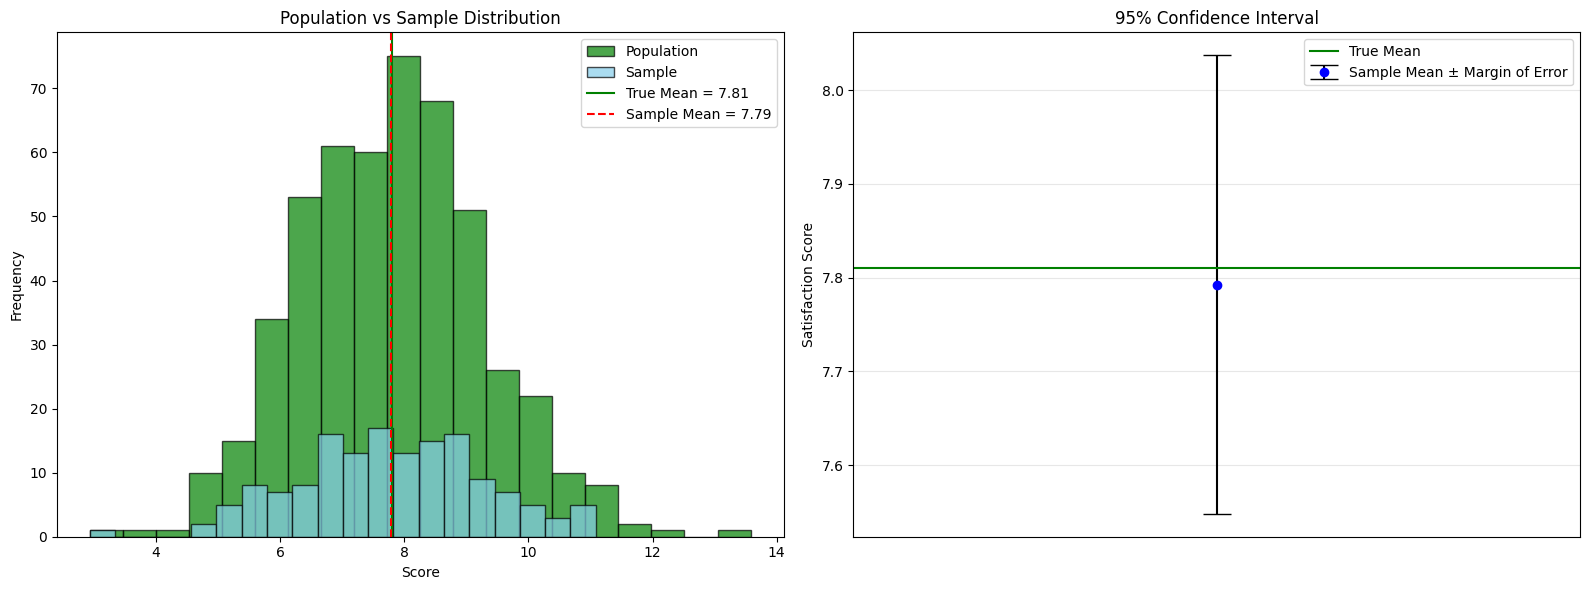

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Step 1: Generate the full population (500 guests) ──────────────────────
np.random.seed(42)
population_size = 500
true_mean = 7.8  # Average satisfaction
true_std = 1.5  # Variation spread
population = np.random.normal(loc=true_mean, scale=true_std, size=population_size)

# ── Step 2: Draw a sample (150 guests) ─────────────────────────────────────
sample_size = 150
sample = np.random.choice(population, size=sample_size, replace=False)
# replace=False:
# Once an element is picked, it cannot be picked again (sampling without replacement).

# ── Step 3: Calculate sample statistics ────────────────────────────────────
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # ddof=1 → unbiased (Bessel's correction)
# ddof=1 divide by n-1 instead of n, which gives an unbiased estimate of the population standard deviation.
confidence_level = 0.95

# ── Step 4: Confidence interval calculation ────────────────────────────────
se = sample_std / np.sqrt(sample_size)  # standard Error
df = sample_size - 1
# ppf: percent-point function (inverse CDF).
# (1 + confidence_level) / 2 = 0.975 captures the middle 95% (two-tailed).
t_critical = stats.t.ppf((1 + confidence_level) / 2, df)
margin_of_error = t_critical * se
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# ── Step 5: Print results ──────────────────────────────────────────────────
print("Customer Satisfaction Survey - Confidence Interval")
print("=" * 60)
print(f"Population size: {population_size}")
print(f"True mean (population): {np.mean(population):.2f}")
print(f"Sample size: {sample_size}")
print(f"Sample mean: {sample_mean:.2f}")
print(f"Sample std dev: {sample_std:.2f}")
print(f"Standard error: {se:.4f}")
print(f"\nConfidence level: {confidence_level:.0%}")
print(f"t-critical value (df={df}): {t_critical:.4f}")
print(f"Margin of error: ±{margin_of_error:.4f}")
print(f"\n{confidence_level:.0%} Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"\nInterpretation: We are {confidence_level:.0%} confident that the true")
print(f"average satisfaction score for ALL hotel guests is between")
print(f"{ci_lower:.2f} and {ci_upper:.2f}.")

# ── Step 6: Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Left: Population vs Sample histogram ──
axes[0].set_facecolor('white')
axes[0].hist(
    population,
    bins=20,
    alpha=0.7,
    label="Population",
    color="green",
    edgecolor="black",
)
axes[0].hist(
    sample, bins=20, alpha=0.7, label="Sample", color="skyblue", edgecolor="black"
)
axes[0].axvline(
    np.mean(population),
    color="green",
    label=f"True Mean = {np.mean(population):.2f}",
)
axes[0].axvline(
    sample_mean, color="red", linestyle="--", label=f"Sample Mean = {sample_mean:.2f}"
)
axes[0].legend()
axes[0].set_title("Population vs Sample Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")
# ── Right: Confidence interval visualization ──
axes[1].set_facecolor('white')
axes[1].errorbar(
    x=1,
    y=sample_mean,
    yerr=margin_of_error,
    fmt='o',
    color='blue',
    ecolor='black',
    capsize=10,
    label=f"Sample Mean ± Margin of Error",
)
axes[1].axhline(np.mean(population), color='green', linestyle='-', label="True Mean")
axes[1].set_xlim(0, 2)
axes[1].set_xticks([])
axes[1].set_title("95% Confidence Interval")
axes[1].set_ylabel("Satisfaction Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

**Key functions & parameters used:**

- `np.random.normal(loc, scale, size)` – generates normally-distributed random data. `loc` = mean, `scale` = standard deviation, `size` = number of samples.
- `np.random.choice(population, size, replace=False)` – draws `size` elements from `population` **without** replacement (no element appears twice).
- `np.std(arr, ddof=1)` – sample standard deviation. `ddof=1` applies **Bessel's correction** (divides by n−1 instead of n) to give an unbiased estimate.
- `stats.t.ppf(q, df)` – **Percent Point Function** (inverse CDF) of the t-distribution. Returns the t-value such that `q` fraction of the distribution lies to its left. We pass `0.975` (= (1 + 0.95)/2) to capture the middle 95% for a two-tailed interval.

**Flow:**
1. We compute `se` (Standard Error) = how much the sample mean varies from sample to sample.
2. `t_critical` gives the "how many standard errors away" threshold.
3. `margin_of_error = t_critical × se` is the half-width of the interval.
4. The CI is `[sample_mean − margin_of_error, sample_mean + margin_of_error]`.

**Output interpretation:**
- Left plot: the sample (blue) is smaller than the population (green), but its distribution shape is similar. The red dashed line (sample mean) is close to but not exactly equal to the green solid line (true mean) — this is expected.
- Right plot: the vertical error bar represents the 95% CI. The green line (true mean) is captured inside the interval — a successful CI.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 4. One-Tailed vs Two-Tailed Tests

<p style="color: steelblue; font-size: 1.5em;">Two-Tailed Test: The "Any Difference" Test</p>

**Goal:** You want to know if a result is just **different** (could be higher OR lower).

- Null hypothesis: H₀: μ = μ₀
- Alternative hypothesis: H₁: μ ≠ μ₀
- You **split** the significance level α **equally between both tails**.
- For 95% confidence: α = 0.05 → each tail = 0.025 → cumulative cutoff = **0.975**
- Decision rule: **reject if |t| > t_critical**

> `t_critical = t.ppf(0.975, df)`

<p style="color: steelblue; font-size: 1.5em;">One-Tailed Test: The "Directional" Test</p>

**Goal:** You only care if a result is **better** (or specifically worse).

- Null hypothesis: H₀: μ ≤ μ₀ (or H₀: μ ≥ μ₀)
- Alternative hypothesis: H₁: μ > μ₀ (or H₁: μ < μ₀)
- **All** α is placed in **one tail**.
- For 95% confidence: α = 0.05 → one tail = 0.05 → cumulative cutoff = **0.95**
- Decision rule: **reject if t > t_critical** (for upper-tailed) or **t < −t_critical** (for lower-tailed)

> `t_critical = t.ppf(0.95, df)`

<p style="color: steelblue; font-size: 1.5em;">Rule of Thumb</p>

| Test Type | Confidence Level | Cumulative Cutoff for `ppf()` |
|-----------|-----------------|-------------------------------|
| Two-tailed | 95% | 0.975 |
| One-tailed | 95% | 0.95 |

> **When to use which?** Use two-tailed when you have no prior reason to expect a direction. Use one-tailed only when you have a strong prior directional hypothesis (e.g., "the new drug can only help, not harm").

</div>


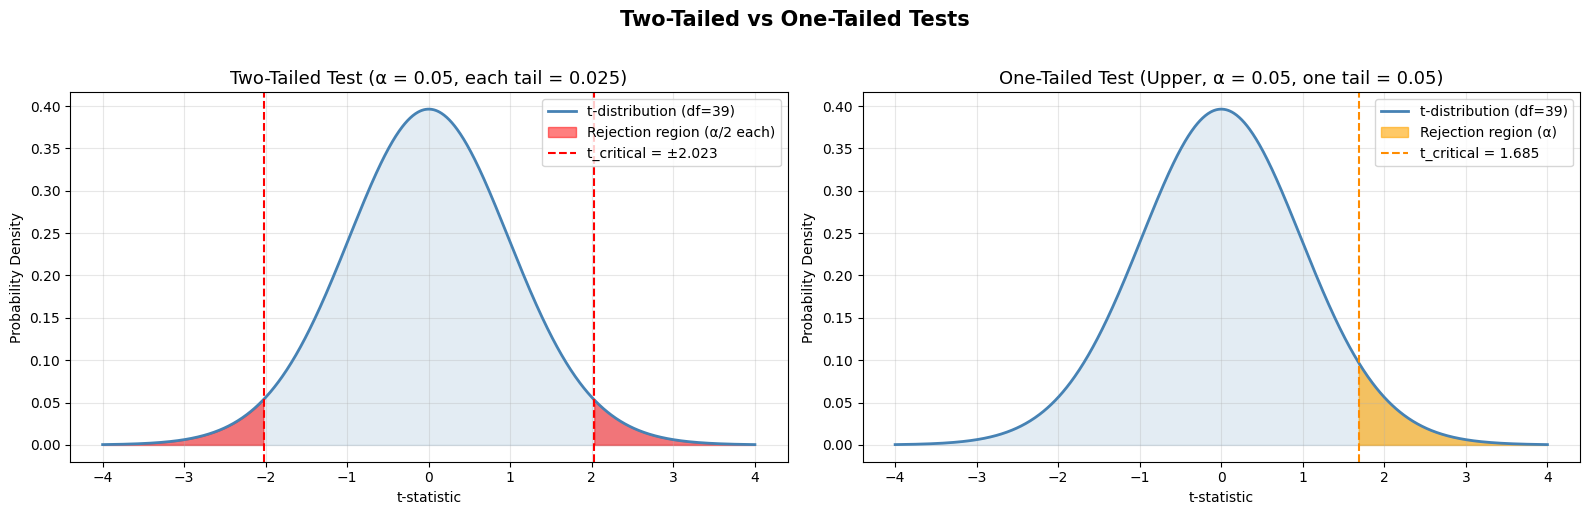

Two-tailed t_critical (df=39, 95% CI): ±2.0227
One-tailed t_critical (df=39, 95%):     1.6849


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')
df = 39  # example degrees of freedom

x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

# ─── LEFT: Two-tailed test ─────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
ax.plot(x, y, 'steelblue', linewidth=2, label='t-distribution (df=39)')
ax.fill_between(x, y, alpha=0.15, color='steelblue')

# It fills the area between two curves (or between a curve and a baseline) with color.
# ax.fill_between(x, y1, y2=0, color, alpha, label, ...)
# y2: The lower curve (default = 0, i.e. the x-axis)

t_crit_2 = stats.t.ppf(0.975, df)  # cutoff = 0.975 for two-tailed 95%
# Shade both rejection regions
ax.fill_between(
    x[x <= -t_crit_2],
    y[x <= -t_crit_2],
    color='red',
    alpha=0.5,
    label='Rejection region (α/2 each)',
)
ax.fill_between(x[x >= t_crit_2], y[x >= t_crit_2], color='red', alpha=0.5)
ax.axvline(-t_crit_2, color='red', linestyle='--', linewidth=1.5)
ax.axvline(
    t_crit_2,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f't_critical = ±{t_crit_2:.3f}',
)
ax.set_title('Two-Tailed Test (α = 0.05, each tail = 0.025)', fontsize=13)
ax.set_xlabel('t-statistic')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ─── RIGHT: One-tailed test (upper) ────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
ax.plot(x, y, 'steelblue', linewidth=2, label='t-distribution (df=39)')
ax.fill_between(x, y, alpha=0.15, color='steelblue')

t_crit_1 = stats.t.ppf(0.95, df)  # cutoff = 0.95 for one-tailed 95%
ax.fill_between(
    x[x >= t_crit_1],
    y[x >= t_crit_1],
    color='orange',
    alpha=0.6,
    label='Rejection region (α)',
)
ax.axvline(
    t_crit_1,
    color='darkorange',
    linestyle='--',
    linewidth=1.5,
    label=f't_critical = {t_crit_1:.3f}',
)
ax.set_title('One-Tailed Test (Upper, α = 0.05, one tail = 0.05)', fontsize=13)
ax.set_xlabel('t-statistic')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Two-Tailed vs One-Tailed Tests', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Two-tailed t_critical (df=39, 95% CI): ±{t_crit_2:.4f}")
print(f"One-tailed t_critical (df=39, 95%):     {t_crit_1:.4f}")


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `stats.t.pdf(x, df)` – **Probability Density Function** of the t-distribution with `df` degrees of freedom. Gives the height of the bell curve at each x value.
- `stats.t.ppf(q, df)` – **Percent Point Function** (inverse CDF). Returns the t-value such that fraction `q` of the distribution is below it.
  - Two-tailed: `ppf(0.975, df)` because each tail has 2.5%.
  - One-tailed: `ppf(0.95, df)` because one tail has 5%.
- `fill_between(x[condition], y[condition], ...)` – shades the rejection region under the curve.

**Key takeaway from the plot:** The two-tailed test has **two** small red regions (one on each side), while the one-tailed test has **one** larger orange region. That's why the one-tailed critical value is smaller (easier to reject H₀) — but only appropriate when you have a directional hypothesis.

</div>



<div style="max-width: 1000px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 5. Type I and Type II Errors

These are the two kinds of mistakes in statistical hypothesis testing:

| | H₀ is actually TRUE | H₀ is actually FALSE |
|---|---|---|
| **Reject H₀** | ❌ Type I Error (False Positive) | ✅ Correct (True Positive) |
| **Fail to Reject H₀** | ✅ Correct (True Negative) | ❌ Type II Error (False Negative) |

<p style="color: steelblue; font-size: 1.5em;">Type I Error (False Positive)</p>

**Definition:** Wrongly rejecting a true null hypothesis — saying there's an effect when there **isn't**.

- **Probability:** α (the significance level you set)
- **Example:** A drug has no effect, but your test concludes it does. You approve a useless drug.
- **Controlled by:** Lowering α (e.g., 0.01 instead of 0.05)

<p style="color: steelblue; font-size: 1.5em;">Type II Error (False Negative)</p>

**Definition:** Failing to reject a false null hypothesis — missing an effect that's **actually there**.

- **Probability:** β (beta)
- **Power of the test = 1 − β** (probability of correctly detecting a real effect)
- **Example:** A new teaching method genuinely works, but your test fails to detect it. A valuable innovation is abandoned.
- **Reduced by:** Increasing sample size, effect size, or significance level

<p style="color: steelblue; font-size: 1.5em;">The Tradeoff</p>

Type I and Type II errors are **tradeoffs**: decreasing one tends to increase the other.

- If you make it **harder to reject** H₀ (lower α), you reduce Type I errors but increase Type II errors (miss more real effects).
- If you make it **easier to reject** H₀ (higher α), you reduce Type II errors but increase Type I errors (more false alarms).

> The best solution is usually to **increase sample size** — this reduces both errors simultaneously.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 6. Choosing the Right Hypothesis Test

| Scenario | Question | Test |
|----------|----------|------|
| **One sample** | Does a sample mean differ from a known value? | One-Sample t-test |
| **Two independent groups (means)** | Are Group A & B means different? | Independent Samples t-test |
| **Two paired groups (means)** | Are "Before" & "After" scores different? | Paired t-test |
| **3+ independent groups (means)** | Are Treatment 1, 2, 3 means different? | One-Way ANOVA |
| **Two categorical variables** | Is there a link between Gender & Pass/Fail? | Chi-Squared Test |

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 7. T-Tests

**T-tests** compare means. They are used when the population standard deviation is **unknown** and the sample size is **small to moderate**.

The core idea: the **t-statistic** measures how many standard errors the sample mean is away from the hypothesized population mean.

```
t = (x̄ − μ₀) / (s / √n)
```

Where:
- `x̄` = sample mean
- `μ₀` = hypothesized population mean (from H₀)
- `s` = sample standard deviation
- `n` = sample size

A large |t| → the sample mean is far from μ₀ → evidence to reject H₀.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 7.1 One-Sample T-Test

**When to use:** Compare a sample mean to a **known population mean or target value**.

**Real-World Case: Quality Control**

A beverage company claims bottles contain 500 ml. Regulatory inspectors test 30 bottles to verify compliance.

- **Null hypothesis H₀:** μ = 500 ml → Bottles meet specifications.
- **Alternative hypothesis H₁:** μ ≠ 500 ml → Bottles do NOT meet specifications.
- **α = 0.05** → 95% confidence level
- **df = n − 1 = 29**

<p style="color: steelblue; font-size: 1.5em;">Reading the t-Table</p>

The t-table gives you the **critical value** — the threshold beyond which you reject H₀.

To find the correct t_critical:
1. Determine **df = n − 1**.
2. Determine **α** and whether test is one-tailed or two-tailed.
3. For a two-tailed test at α = 0.05: use the column labelled "0.025" (since α/2 = 0.025).
4. Find the row for your df.
5. The value at that intersection is t_critical ≈ 2.045 for df = 29.

If **|t_statistic| > t_critical**, reject H₀. Equivalently, if **p-value < α**, reject H₀.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Using One-Sample T-Test in ML Research Papers</p>

In machine learning research, the one-sample t-test is used to **prove that a model's performance is significantly different from a known baseline or threshold**, rather than attributing the result to random variation due to the data split.

**Classification research:**

Suppose your classification model achieves a mean accuracy of 87.4% across 10 cross-validation folds. You want to prove it significantly outperforms a known industry baseline of 85%.

- **H₀:** μ_accuracy = 0.85 (the model's true accuracy equals the baseline)
- **H₁:** μ_accuracy ≠ 0.85 (the model significantly differs from the baseline)
- You apply a one-sample t-test on the 10 fold accuracies against the value 0.85.
- If p < 0.05 → your model is statistically significantly different from the baseline. You can claim this result in a paper.

**Regression research:**

Your regression model yields a mean RMSE of 4.2 across 10 folds. The published state-of-the-art reports an RMSE of 5.0. You want to verify the improvement is not by chance.

- **H₀:** μ_RMSE = 5.0 (your model is no better than the benchmark)
- **H₁:** μ_RMSE < 5.0 (one-tailed: your model has significantly lower error)
- A one-sample t-test on fold RMSE values against 5.0 gives statistical backing.

> **Why this matters in papers:** Reviewers often ask "is this improvement statistically significant or just lucky data splits?" The one-sample t-test provides rigorous evidence.

</div>


One-Sample T-Test: Bottle Volume Quality Control
H₀: μ = 500 ml (bottles meet specifications)
H₁: μ ≠ 500 ml (bottles do NOT meet specifications)

Sample size: 30
Sample mean: 497.06 ml
Sample std dev: 4.50 ml
Standard error: 0.8216

Test Results:
  t-statistic: -3.5793
  t-critical (df=29, two-tailed 95%): 2.0452
  p-value: 0.0012
  95% CI: [495.38, 498.74] ml

✗ REJECT H₀ (p = 0.0012 < α = 0.05)
  Conclusion: Bottles are significantly different from 500ml
  Regulatory action: FAIL - investigate production line


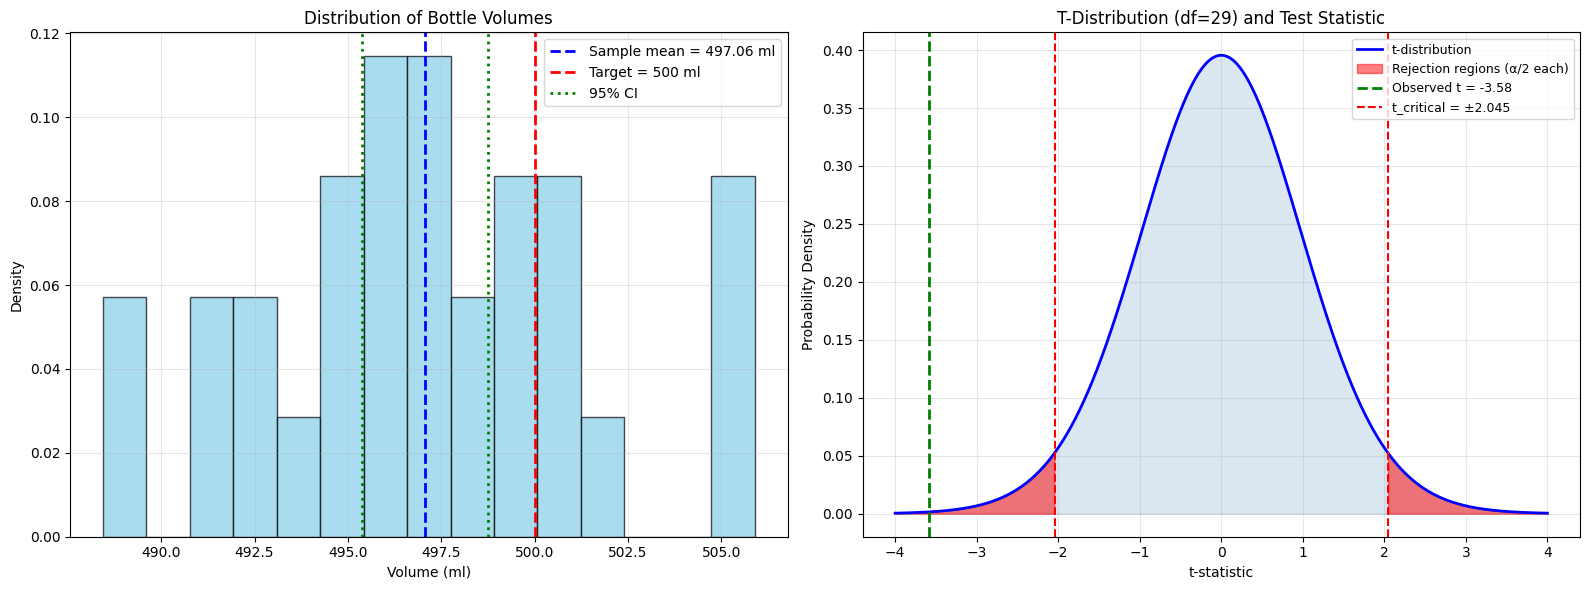

In [28]:
from scipy.stats import ttest_1samp
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ── Generate sample data ───────────────────────────────────────────────────
np.random.seed(42)
target_volume = 500  # claimed/target value (μ₀)
# Simulating 30 bottles filled at mean=498 (slightly underfilled), std=5
measured_volumes = np.random.normal(498, 5, 30)

# ── Perform one-sample t-test ─────────────────────────────────────────────
# ttest_1samp(a, popmean): tests if mean of array a equals popmean
t_statistic, p_value = ttest_1samp(measured_volumes, target_volume)

# ── Calculate confidence interval ─────────────────────────────────────────
sample_mean = np.mean(measured_volumes)
sample_std = np.std(measured_volumes, ddof=1)
n = len(measured_volumes)
se = sample_std / np.sqrt(n)
df = n - 1
# 0.975 → two-tailed 95% CI: middle 95% leaves 2.5% in each tail
t_crit = stats.t.ppf(0.975, df)
ci_lower = sample_mean - t_crit * se
ci_upper = sample_mean + t_crit * se

print("One-Sample T-Test: Bottle Volume Quality Control")
print("=" * 60)
print(f"H₀: μ = {target_volume} ml (bottles meet specifications)")
print(f"H₁: μ ≠ {target_volume} ml (bottles do NOT meet specifications)")
print(f"\nSample size: {n}")
print(f"Sample mean: {sample_mean:.2f} ml")
print(f"Sample std dev: {sample_std:.2f} ml")
print(f"Standard error: {se:.4f}")
print(f"\nTest Results:")
print(f"  t-statistic: {t_statistic:.4f}")
print(f"  t-critical (df={df}, two-tailed 95%): {t_crit:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  95% CI: [{ci_lower:.2f}, {ci_upper:.2f}] ml")

alpha = 0.05
if p_value < alpha:
    print(f"\n✗ REJECT H₀ (p = {p_value:.4f} < α = {alpha})")
    print(f"  Conclusion: Bottles are significantly different from {target_volume}ml")
    print(f"  Regulatory action: FAIL - investigate production line")
else:
    print(f"\n✓ FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print(
        f"  Conclusion: No significant evidence bottles differ from {target_volume}ml"
    )
    print(f"  Regulatory action: PASS")

# ── Visualize ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Left: Distribution of measurements ──
axes[0].set_facecolor('white')
axes[0].hist(
    measured_volumes,
    bins=15,
    alpha=0.7,
    density=True,
    color='skyblue',
    edgecolor='black',
)
axes[0].axvline(
    sample_mean,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Sample mean = {sample_mean:.2f} ml',
)
axes[0].axvline(
    target_volume,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Target = {target_volume} ml',
)
axes[0].axvline(ci_lower, color='green', linestyle=':', linewidth=2, label='95% CI')
axes[0].axvline(ci_upper, color='green', linestyle=':', linewidth=2)
axes[0].set_xlabel('Volume (ml)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Bottle Volumes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: T-distribution with test statistic ──
axes[1].set_facecolor('white')
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

axes[1].plot(x, y, 'b-', linewidth=2, label='t-distribution')
axes[1].fill_between(x, y, alpha=0.2, color='steelblue')

# Shade rejection regions
axes[1].fill_between(
    x[x <= -t_crit],
    stats.t.pdf(x[x <= -t_crit], df),
    alpha=0.5,
    color='red',
    label='Rejection regions (α/2 each)',
)
axes[1].fill_between(
    x[x >= t_crit], stats.t.pdf(x[x >= t_crit], df), alpha=0.5, color='red'
)
# Mark observed t-statistic
axes[1].axvline(
    t_statistic,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Observed t = {t_statistic:.2f}',
)
axes[1].axvline(
    -t_crit,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f't_critical = ±{t_crit:.3f}',
)
axes[1].axvline(t_crit, color='red', linestyle='--', linewidth=1.5)

axes[1].set_xlabel('t-statistic')
axes[1].set_ylabel('Probability Density')
axes[1].set_title(f'T-Distribution (df={df}) and Test Statistic')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `ttest_1samp(a, popmean)` – performs a one-sample t-test.
  - `a` = array of sample observations.
  - `popmean` = the hypothesized population mean (H₀ value).
  - Returns `(t_statistic, p_value)`. The p-value is for a **two-tailed** test.
- `stats.t.ppf(0.975, df)` – finds t_critical for a two-tailed 95% test.

**Interpreting the t-distribution plot:**
- The bell curve is the t-distribution under H₀.
- Red shaded regions = rejection zones (extreme values beyond ±t_critical).
- Green dashed line = observed t-statistic.
- If the green line falls in the red zone → reject H₀.
- Note: The 95% CI on the left plot does NOT contain 500 ml → confirms rejection of H₀.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Example: Fail to Reject H₀ (Bottles PASS)</p>

Now let's simulate bottles that are actually filled at 500 ml (no defect). We should fail to reject H₀.

</div>


One-Sample T-Test: Bottles PASS scenario
Sample mean: 499.63 ml  (target: 500 ml)
t-statistic: -0.3959
t-critical:  ±2.0452
p-value:     0.6950

✓ FAIL TO REJECT H₀ — bottles meet specifications (PASS)


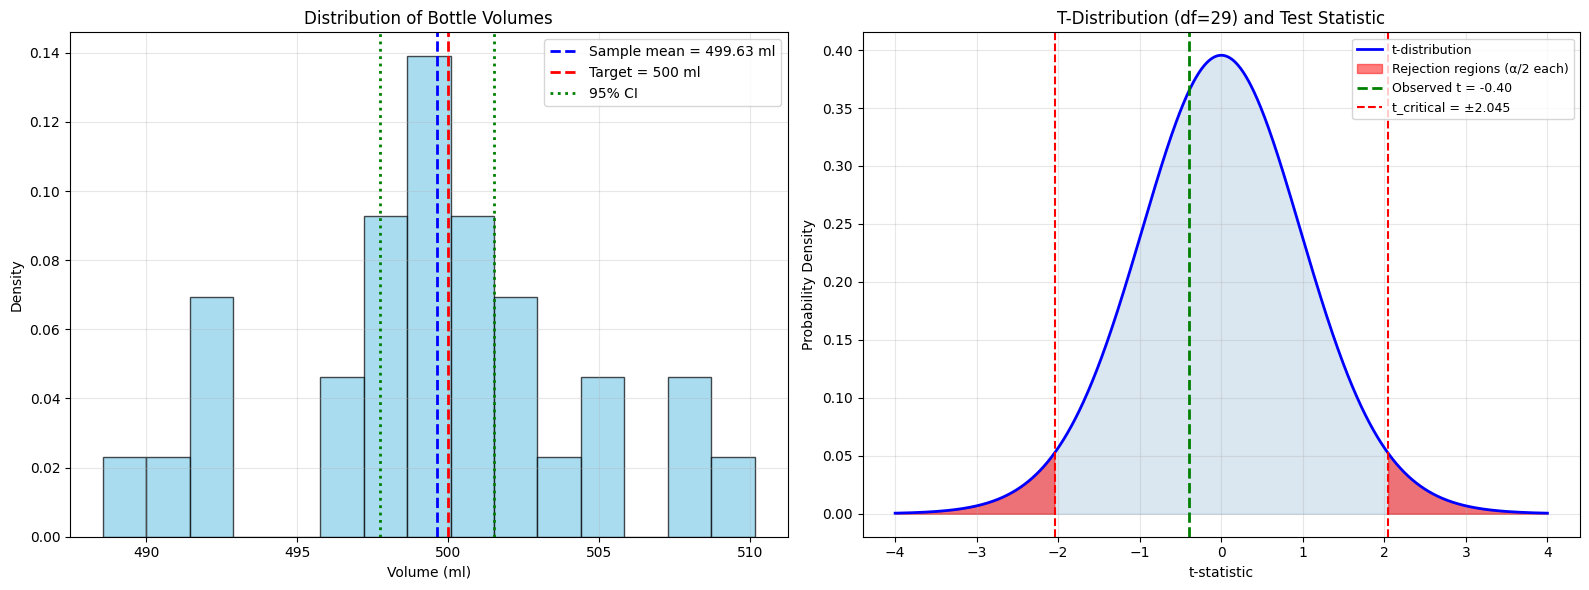

In [29]:
from scipy.stats import ttest_1samp
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Bottles correctly filled (mean = 500 ml — same as target)
np.random.seed(7)
target_volume_pass = 500
pass_volumes = np.random.normal(500, 5, 30)  # mean = target → no defect

t_stat_pass, p_val_pass = ttest_1samp(pass_volumes, target_volume_pass)
df_pass = len(pass_volumes) - 1
t_crit_p = stats.t.ppf(0.975, df_pass)

# ── Calculate confidence interval ─────────────────────────────────────────
sample_mean_p = np.mean(pass_volumes)
sample_std_p = np.std(pass_volumes, ddof=1)
n_p = len(pass_volumes)
se_p = sample_std_p / np.sqrt(n_p)
ci_lower_p = sample_mean_p - t_crit_p * se_p
ci_upper_p = sample_mean_p + t_crit_p * se_p

print("One-Sample T-Test: Bottles PASS scenario")
print("=" * 50)
print(f"Sample mean: {np.mean(pass_volumes):.2f} ml  (target: {target_volume_pass} ml)")
print(f"t-statistic: {t_stat_pass:.4f}")
print(f"t-critical:  ±{t_crit_p:.4f}")
print(f"p-value:     {p_val_pass:.4f}")

if p_val_pass < 0.05:
    print("\n✗ REJECT H₀ — quality issue detected!")
else:
    print("\n✓ FAIL TO REJECT H₀ — bottles meet specifications (PASS)")

# ── Visualize ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Left: Distribution of measurements ──
axes[0].set_facecolor('white')
axes[0].hist(
    pass_volumes,
    bins=15,
    alpha=0.7,
    density=True,
    color='skyblue',
    edgecolor='black',
)
axes[0].axvline(
    pass_volumes.mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Sample mean = {pass_volumes.mean():.2f} ml',
)
axes[0].axvline(
    target_volume_pass,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Target = {target_volume_pass} ml',
)
axes[0].axvline(ci_lower_p, color='green', linestyle=':', linewidth=2, label='95% CI')
axes[0].axvline(ci_upper_p, color='green', linestyle=':', linewidth=2)
axes[0].set_xlabel('Volume (ml)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Bottle Volumes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: T-distribution with test statistic ──
axes[1].set_facecolor('white')
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df_pass)

axes[1].plot(x, y, 'b-', linewidth=2, label='t-distribution')
axes[1].fill_between(x, y, alpha=0.2, color='steelblue')

# Shade rejection regions
axes[1].fill_between(
    x[x <= -t_crit_p],
    stats.t.pdf(x[x <= -t_crit_p], df_pass),
    alpha=0.5,
    color='red',
    label='Rejection regions (α/2 each)',
)
axes[1].fill_between(
    x[x >= t_crit_p], stats.t.pdf(x[x >= t_crit_p], df_pass), alpha=0.5, color='red'
)
# Mark observed t-statistic
axes[1].axvline(
    t_stat_pass,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Observed t = {t_stat_pass:.2f}',
)
axes[1].axvline(
    -t_crit_p,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f't_critical = ±{t_crit_p:.3f}',
)
axes[1].axvline(t_crit_p, color='red', linestyle='--', linewidth=1.5)

axes[1].set_xlabel('t-statistic')
axes[1].set_ylabel('Probability Density')
axes[1].set_title(f'T-Distribution (df={df_pass}) and Test Statistic')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

Here we generated samples from a distribution with `mean=500`, which is exactly equal to the target. The t-statistic is near 0 (close to the center of the distribution) and the p-value is large → we fail to reject H₀. This is the correct outcome: the bottles are fine.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Reject H₀: Model Accuracy Significantly Exceeds Baseline</p>

A classification model is trained and evaluated on 10 cross-validation folds. The published baseline accuracy is **0.80 (80%)**. We want to confirm that the model's mean accuracy is significantly above this threshold — not just a lucky split.

- **H₀:** μ_accuracy = 0.80 (not better than baseline)
- **H₁:** μ_accuracy ≠ 0.80 (significantly different from baseline)
- **α = 0.05**

</div>


One-Sample T-Test: ML Model Accuracy vs Published Baseline
H₀: μ_accuracy = 0.8  (no improvement over baseline)
H₁: μ_accuracy ≠ 0.8  (significantly different)

10-fold CV accuracies: [0.9    0.8889 0.8482 0.8758 0.8872 0.863  0.8808 0.878  0.8761 0.8729]
Sample mean accuracy: 0.8771
Std dev: 0.0143  |  SE: 0.0045

t-statistic: 17.0831
t-critical (df=9): ±2.2622
p-value: 0.000000
95% CI: [0.8669, 0.8873]

✓ REJECT H₀ (p < 0.05)
  The model's accuracy (87.71%) is statistically
  significantly different from the baseline (80.00%).
  The CI [86.69%, 88.73%] lies entirely above baseline.
  → Paper claim: Our model significantly outperforms the baseline (p=0.0000).


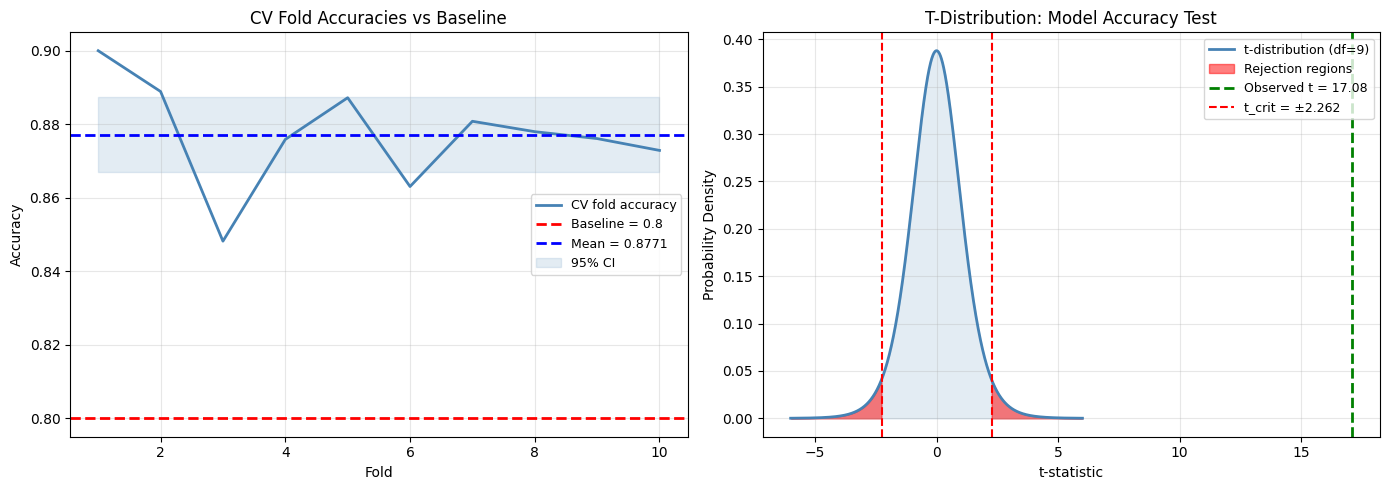

In [30]:
from scipy.stats import ttest_1samp
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Cross-validation fold accuracies of a classification model (10 folds)
# These represent per-fold test accuracy scores (e.g., from a random forest)
np.random.seed(10)
baseline_accuracy = 0.80  # Known published baseline (μ₀)
# Simulating 10 fold accuracies with mean ≈ 0.876 — clearly above baseline
cv_accuracies = np.random.normal(0.876, 0.018, 10)

# One-sample t-test: are these accuracies significantly different from baseline?
t_stat_ml, p_val_ml = ttest_1samp(cv_accuracies, baseline_accuracy)

sample_mean_ml = np.mean(cv_accuracies)
sample_std_ml = np.std(cv_accuracies, ddof=1)  # Fix: missing '=' operator
n_ml = len(cv_accuracies)
se_ml = sample_std_ml / np.sqrt(n_ml)
df_ml = n_ml - 1
t_crit_ml = stats.t.ppf(0.975, df_ml)
ci_lo = sample_mean_ml - t_crit_ml * se_ml
ci_hi = sample_mean_ml + t_crit_ml * se_ml

print("One-Sample T-Test: ML Model Accuracy vs Published Baseline")
print("=" * 60)
print(f"H₀: μ_accuracy = {baseline_accuracy}  (no improvement over baseline)")
print(f"H₁: μ_accuracy ≠ {baseline_accuracy}  (significantly different)")
print(f"\n10-fold CV accuracies: {np.round(cv_accuracies, 4)}")
print(f"Sample mean accuracy: {sample_mean_ml:.4f}")
print(f"Std dev: {sample_std_ml:.4f}  |  SE: {se_ml:.4f}")
print(f"\nt-statistic: {t_stat_ml:.4f}")
print(f"t-critical (df={df_ml}): ±{t_crit_ml:.4f}")
print(f"p-value: {p_val_ml:.6f}")
print(f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")

alpha = 0.05
if p_val_ml < alpha:
    print(f"\n✓ REJECT H₀ (p < {alpha})")
    print(f"  The model's accuracy ({sample_mean_ml:.2%}) is statistically")
    print(f"  significantly different from the baseline ({baseline_accuracy:.2%}).")
    print(f"  The CI [{ci_lo:.2%}, {ci_hi:.2%}] lies entirely above baseline.")
    print(
        f"  → Paper claim: Our model significantly outperforms the baseline (p={p_val_ml:.4f})."
    )
else:
    print(f"\n✗ FAIL TO REJECT H₀: No significant improvement shown")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# Left: fold accuracies vs baseline
axes[0].set_facecolor('white')
axes[0].plot(
    range(1, 11),
    cv_accuracies,
    color='steelblue',
    linewidth=2,
    label='CV fold accuracy',
)
axes[0].axhline(
    baseline_accuracy,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Baseline = {baseline_accuracy}',
)
axes[0].axhline(
    sample_mean_ml,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {sample_mean_ml:.4f}',
)
axes[0].fill_between(
    range(1, 11), ci_lo, ci_hi, alpha=0.15, color='steelblue', label='95% CI'
)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CV Fold Accuracies vs Baseline')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: t-distribution
x_t = np.linspace(-6, 6, 1000)
y_t = stats.t.pdf(x_t, df_ml)  # Fix: incomplete expression
axes[1].set_facecolor('white')
axes[1].plot(x_t, y_t, 'steelblue', linewidth=2, label=f't-distribution (df={df_ml})')
axes[1].fill_between(x_t, y_t, alpha=0.15, color='steelblue')
axes[1].fill_between(
    x_t[x_t <= -t_crit_ml],
    stats.t.pdf(x_t[x_t <= -t_crit_ml], df_ml),
    color='red',
    alpha=0.5,
    label='Rejection regions',
)
axes[1].fill_between(
    x_t[x_t >= t_crit_ml],
    stats.t.pdf(x_t[x_t >= t_crit_ml], df_ml),
    color='red',
    alpha=0.5,
)
axes[1].axvline(
    t_stat_ml,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Observed t = {t_stat_ml:.2f}',
)
axes[1].axvline(t_crit_ml, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(
    -t_crit_ml,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f't_crit = ±{t_crit_ml:.3f}',
)
axes[1].set_xlabel('t-statistic')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('T-Distribution: Model Accuracy Test')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `cv_accuracies` represents the accuracy score of our classifier on each of 10 cross-validation folds. These are our "sample" of 10 measurements.
- `baseline_accuracy = 0.80` is the known benchmark μ₀ — the value we test against.
- `ttest_1samp(cv_accuracies, 0.80)` tests whether the mean of these 10 fold scores is statistically different from 0.80.
- Because the 95% CI lies entirely above the baseline, and the t-statistic is deep in the rejection region, we can **claim in a research paper** that the improvement is statistically significant.

**ML paper reporting format:**
> "The proposed model achieved a mean 10-fold CV accuracy of 87.6% (95% CI: [86.5%, 88.7%]), significantly exceeding the published baseline of 80% (one-sample t-test: t(9) = XX, p < 0.001)."

</div>



<div style="max-width: 1000px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Fail to Reject H₀: Model Performance Not Significantly Above Baseline</p>

A regression model is evaluated across 10 folds. The benchmark RMSE is **4.50**. Despite a slightly lower mean RMSE, we test whether this improvement is statistically significant.

- **H₀:** μ_RMSE = 4.50 (same performance as benchmark)
- **H₁:** μ_RMSE ≠ 4.50
- **α = 0.05**

</div>


One-Sample T-Test: Regression Model RMSE vs Benchmark
H₀: μ_RMSE = 4.5  (no improvement over benchmark)
H₁: μ_RMSE ≠ 4.5

10-fold RMSE values: [4.3924 3.981  4.7445 4.3482 4.2727 4.1193 4.6956 4.0889 4.6079 4.2515]
Mean RMSE: 4.3502  (benchmark: 4.5)
t-statistic: -1.8095
p-value: 0.1038

✗ FAIL TO REJECT H₀ (p = 0.1038 ≥ 0.05)
  Although mean RMSE (4.3502) < benchmark (4.5),
  the difference is NOT statistically significant.
  → Paper claim: We cannot claim our model outperforms the benchmark (p=0.1038).
  → Action: Collect more data or improve the model before claiming superiority.


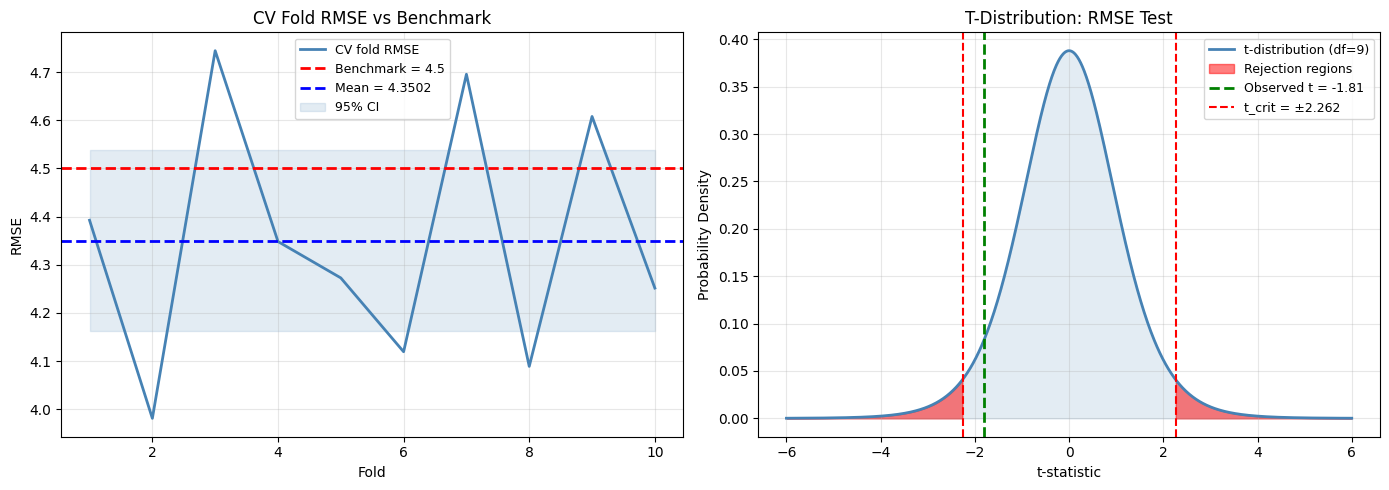

In [31]:
from scipy.stats import ttest_1samp
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Fold-level RMSE values of a regression model (10 folds)
# Mean ≈ 4.42 — slightly below benchmark, but with high variance
np.random.seed(22)
benchmark_rmse = 4.50  # Published benchmark RMSE (μ₀)
# High std dev → noisy folds → improvement may not be real
cv_rmse = np.random.normal(4.42, 0.30, 10)

t_rmse, p_rmse = ttest_1samp(cv_rmse, benchmark_rmse)

sample_mean_rmse = np.mean(cv_rmse)
sample_std_rmse = np.std(cv_rmse, ddof=1)
n_rmse = len(cv_rmse)
se_rmse = sample_std_rmse / np.sqrt(n_rmse)
df_rmse = n_rmse - 1
t_crit_rmse = stats.t.ppf(0.975, df_rmse)
ci_lo = sample_mean_rmse - t_crit_rmse * se_rmse
ci_hi = sample_mean_rmse + t_crit_rmse * se_rmse

print("One-Sample T-Test: Regression Model RMSE vs Benchmark")
print("=" * 60)
print(f"H₀: μ_RMSE = {benchmark_rmse}  (no improvement over benchmark)")
print(f"H₁: μ_RMSE ≠ {benchmark_rmse}")
print(f"\n10-fold RMSE values: {np.round(cv_rmse, 4)}")
print(f"Mean RMSE: {sample_mean_rmse:.4f}  (benchmark: {benchmark_rmse})")
print(f"t-statistic: {t_rmse:.4f}")
print(f"p-value: {p_rmse:.4f}")

if p_rmse < 0.05:
    print("\n✓ REJECT H₀ — improvement is statistically significant")
else:
    print(f"\n✗ FAIL TO REJECT H₀ (p = {p_rmse:.4f} ≥ 0.05)")
    print(
        f"  Although mean RMSE ({sample_mean_rmse:.4f}) < benchmark ({benchmark_rmse}),"
    )
    print(f"  the difference is NOT statistically significant.")
    print(
        f"  → Paper claim: We cannot claim our model outperforms the benchmark (p={p_rmse:.4f})."
    )
    print(
        f"  → Action: Collect more data or improve the model before claiming superiority."
    )

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# Left: fold RMSE values vs benchmark
axes[0].set_facecolor('white')
axes[0].plot(
    range(1, 11),
    cv_rmse,
    color='steelblue',
    linewidth=2,
    label='CV fold RMSE',
)
axes[0].axhline(
    benchmark_rmse,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Benchmark = {benchmark_rmse}',
)
axes[0].axhline(
    sample_mean_rmse,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {sample_mean_rmse:.4f}',
)
axes[0].fill_between(
    range(1, 11), ci_lo, ci_hi, alpha=0.15, color='steelblue', label='95% CI'
)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].set_title('CV Fold RMSE vs Benchmark')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: t-distribution
x_t = np.linspace(-6, 6, 1000)
y_t = stats.t.pdf(x_t, df_rmse)
axes[1].set_facecolor('white')
axes[1].plot(x_t, y_t, 'steelblue', linewidth=2, label=f't-distribution (df={df_rmse})')
axes[1].fill_between(x_t, y_t, alpha=0.15, color='steelblue')
axes[1].fill_between(
    x_t[x_t <= -t_crit_rmse],
    stats.t.pdf(x_t[x_t <= -t_crit_rmse], df_rmse),
    color='red',
    alpha=0.5,
    label='Rejection regions',
)
axes[1].fill_between(
    x_t[x_t >= t_crit_rmse],
    stats.t.pdf(x_t[x_t >= t_crit_rmse], df_rmse),
    color='red',
    alpha=0.5,
)
axes[1].axvline(
    t_rmse,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Observed t = {t_rmse:.2f}',
)
axes[1].axvline(t_crit_rmse, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(
    -t_crit_rmse,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f't_crit = ±{t_crit_rmse:.3f}',
)
axes[1].set_xlabel('t-statistic')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('T-Distribution: RMSE Test')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- Even though the mean RMSE is slightly lower than the benchmark, the **high variability across folds** (std ≈ 0.30) means the difference could easily be due to chance.
- The t-statistic is small and the p-value is large → we cannot confidently say the model beats the benchmark.
- This is a critical finding in ML research: **do not claim improvement without statistical backing**. A lower number on the test set alone is not enough — it must be significantly lower.

**ML paper reporting format:**
> "The proposed model's mean RMSE of 4.42 across 10 folds did not significantly differ from the benchmark RMSE of 4.50 (one-sample t-test: t(9) = XX, p = 0.XX, n.s.), suggesting the improvement may be attributable to variance in data splits rather than model superiority."

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 7.2 Two-Sample T-Test (Independent)

**When to use:** Compare means of **two independent groups** — groups with no inherent pairing between their members.

**Real-World Case: Marketing Campaign Comparison**

A company runs two marketing campaigns (A and B) in different regions. The goal: compare average sales between the two campaigns to see if one performs significantly better.

- **H₀:** μ_A = μ_B → both campaigns have the same average sales.
- **H₁:** μ_A ≠ μ_B → campaigns differ in average sales.
- **α = 0.05**, **df = n₁ + n₂ − 2**

<p style="color: steelblue; font-size: 1.5em;">What the p-value really means here</p>

Think of the t-statistic as a point on a bell curve. That curve represents the distribution of differences between group means **if H₀ were true** (i.e., if both groups had the same true mean). The p-value is the area under that curve beyond your observed t — the probability of seeing a difference this large or larger by chance.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Using Two-Sample T-Test in ML Research Papers</p>

The two-sample (independent) t-test is the most commonly used test in ML papers to **compare two models** or **two configurations** trained independently.

**Classification research:**

You have two different model architectures (e.g., Model A and Model B). Each is evaluated independently on 10 cross-validation folds. The fold-level accuracy scores are independent between models.

- **H₀:** μ_A = μ_B (both models achieve the same true accuracy)
- **H₁:** μ_A ≠ μ_B (the models differ significantly)
- Apply `ttest_ind(accuracy_A, accuracy_B)`.
- A significant result → you can claim one architecture is statistically better.

**Regression research:**

Compare two feature sets: the original features vs. a new engineered feature set. Each is evaluated on separate k-fold splits. You want to prove the new features significantly reduce RMSE.

- **H₀:** μ_RMSE_original = μ_RMSE_new
- **H₁:** μ_RMSE_original ≠ μ_RMSE_new (one-tailed: new < original)
- `ttest_ind(rmse_original, rmse_new, alternative='greater')` for directional claim.

> **Important caveat:** If both models are evaluated on the **same** data splits, use the Paired T-Test (7.3) instead — it is more statistically powerful because it controls for fold-level variance.

</div>


Two-Sample T-Test: Marketing Campaign Comparison
H₀: μ_A = μ_B  (same average sales)
H₁: μ_A ≠ μ_B  (different average sales)

Campaign A (n=50): Mean = $4,729.43,  Std = $1,120.40
Campaign B (n=50): Mean = $5,523.12,  Std = $1,136.62

Difference: $793.68

Test Results:
  t-statistic: -3.5164
  t-critical (df=98, two-tailed 95%): ±1.9845
  p-value: 0.0007

✓ REJECT H₀ (p < 0.05): Campaign B significantly outperforms A
  Business decision: Expand Campaign B strategy


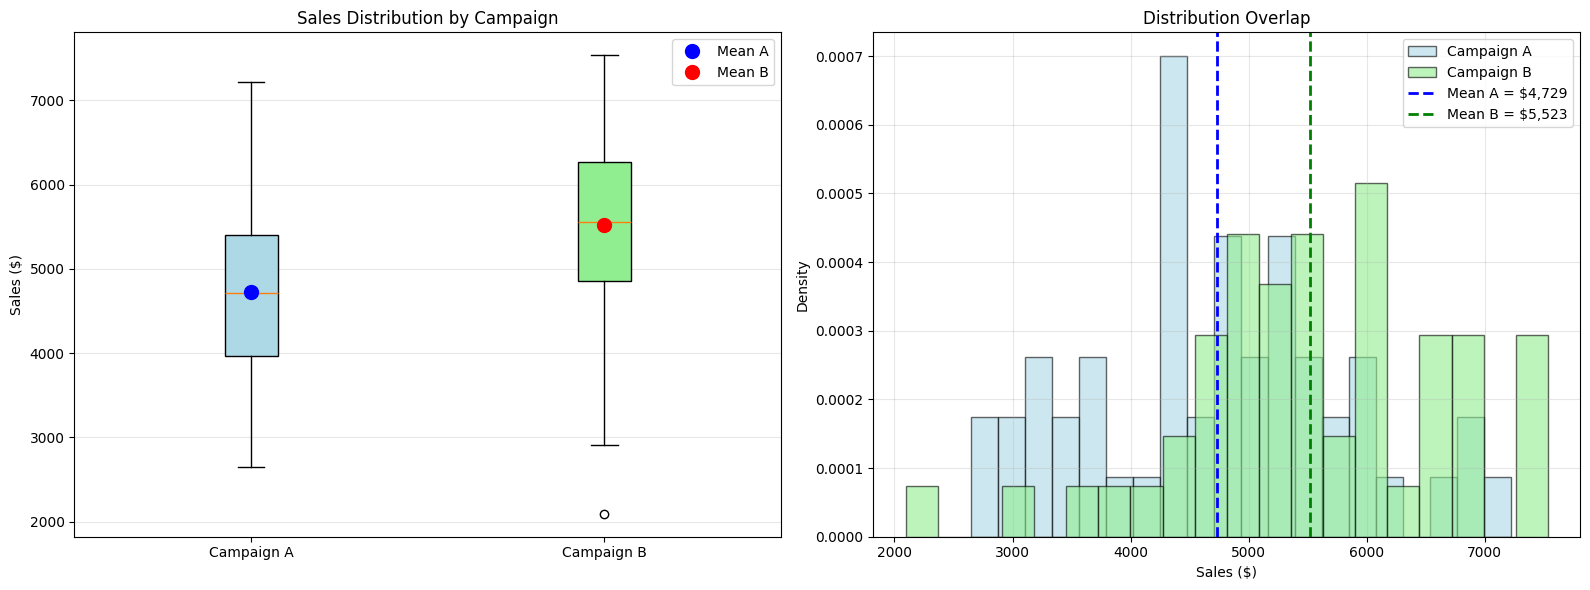


ROI Analysis for Campaign B:
  Additional revenue per customer: $793.68
  Total additional revenue: $39,684.19
  Campaign cost: $10,000.00
  Net benefit: $29,684.19


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ── Step 1: Generate synthetic data ───────────────────────────────────────
np.random.seed(42)
# Campaign A: mean ≈ $5000, std dev ≈ $1200, 50 samples
campaign_a_sales = np.random.normal(5000, 1200, 50)
# Campaign B: mean ≈ $5500, std dev ≈ $1300, 50 samples
campaign_b_sales = np.random.normal(5500, 1300, 50)

# ── Step 2: Two-sample t-test ─────────────────────────────────────────────
# ttest_ind(a, b): independent-samples t-test (two-tailed by default)
t_stat, p_value = ttest_ind(campaign_a_sales, campaign_b_sales)

# ── Step 3: Compute statistics ────────────────────────────────────────────
mean_a = np.mean(campaign_a_sales)
mean_b = np.mean(campaign_b_sales)
std_a = np.std(campaign_a_sales, ddof=1)
std_b = np.std(campaign_b_sales, ddof=1)
n_a = len(campaign_a_sales)
n_b = len(campaign_b_sales)
df_2 = n_a + n_b - 2

from scipy import stats as st

t_critical = st.t.ppf(0.975, df_2)

print("Two-Sample T-Test: Marketing Campaign Comparison")
print("=" * 60)
print(f"H₀: μ_A = μ_B  (same average sales)")
print(f"H₁: μ_A ≠ μ_B  (different average sales)")
print(f"\nCampaign A (n={n_a}): Mean = ${mean_a:,.2f},  Std = ${std_a:,.2f}")
print(f"Campaign B (n={n_b}): Mean = ${mean_b:,.2f},  Std = ${std_b:,.2f}")
print(f"\nDifference: ${mean_b - mean_a:,.2f}")
print(f"\nTest Results:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  t-critical (df={df_2}, two-tailed 95%): ±{t_critical:.4f}")
print(f"  p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✓ REJECT H₀ (p < {alpha}): Campaign B significantly outperforms A")
    if mean_b > mean_a:
        print(f"  Business decision: Expand Campaign B strategy")
else:
    print(f"\n✗ FAIL TO REJECT H₀ (p ≥ {alpha}): No significant difference")
    print(f"  Business decision: Either campaign is acceptable")

# ── Step 5: Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Left: Boxplot ──
axes[0].set_facecolor('white')
bp = axes[0].boxplot(
    [campaign_a_sales, campaign_b_sales],
    tick_labels=['Campaign A', 'Campaign B'],
    patch_artist=True,
)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen']):
    patch.set_facecolor(color)
axes[0].set_ylabel('Sales ($)')
axes[0].set_title('Sales Distribution by Campaign')
axes[0].grid(axis='y', alpha=0.3)
axes[0].plot(1, mean_a, 'bo', markersize=10, label='Mean A', zorder=5)
axes[0].plot(2, mean_b, 'ro', markersize=10, label='Mean B', zorder=5)
axes[0].legend()

# ── Right: Overlapping distributions ──
axes[1].set_facecolor('white')
axes[1].hist(
    campaign_a_sales,
    bins=20,
    alpha=0.6,
    label='Campaign A',
    edgecolor='black',
    density=True,
    color='lightblue',
)
axes[1].hist(
    campaign_b_sales,
    bins=20,
    alpha=0.6,
    label='Campaign B',
    edgecolor='black',
    density=True,
    color='lightgreen',
)
axes[1].axvline(
    mean_a, color='blue', linestyle='--', linewidth=2, label=f'Mean A = ${mean_a:,.0f}'
)
axes[1].axvline(
    mean_b, color='green', linestyle='--', linewidth=2, label=f'Mean B = ${mean_b:,.0f}'
)
axes[1].set_xlabel('Sales ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution Overlap')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── ROI Analysis ──────────────────────────────────────────────────────────
cost_per_campaign = 10000
if mean_b > mean_a and p_value < alpha:
    additional_roi = (mean_b - mean_a) * n_b - cost_per_campaign
    print(f"\nROI Analysis for Campaign B:")
    print(f"  Additional revenue per customer: ${mean_b - mean_a:,.2f}")
    print(f"  Total additional revenue: ${(mean_b - mean_a) * n_b:,.2f}")
    print(f"  Campaign cost: ${cost_per_campaign:,.2f}")
    print(f"  Net benefit: ${additional_roi:,.2f}")


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `ttest_ind(a, b)` – independent-samples (two-sample) t-test.
  - `a`, `b` = arrays of observations for each group.
  - Returns `(t_statistic, p_value)`. Two-tailed by default.

- **df = n₁ + n₂ − 2** for the standard two-sample t-test (one df "used" by each group's sample mean estimate).

**Box plot interpretation:** The boxes show the interquartile range (25th–75th percentiles). The red dots mark the group means. If the boxes overlap heavily, differences may not be significant; if clearly separated, one campaign likely outperforms.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Example: Fail to Reject H₀ (No significant difference)</p>

Let's simulate two campaigns with nearly identical means — we expect to fail to reject H₀.

</div>


Two-Sample T-Test: No Significant Difference scenario
Mean A: $5,004.98  |  Mean B: $5,188.59
t-statistic: -0.7658
p-value:     0.4456

✗ FAIL TO REJECT H₀ — no significant difference between campaigns
   Business decision: Either campaign is acceptable


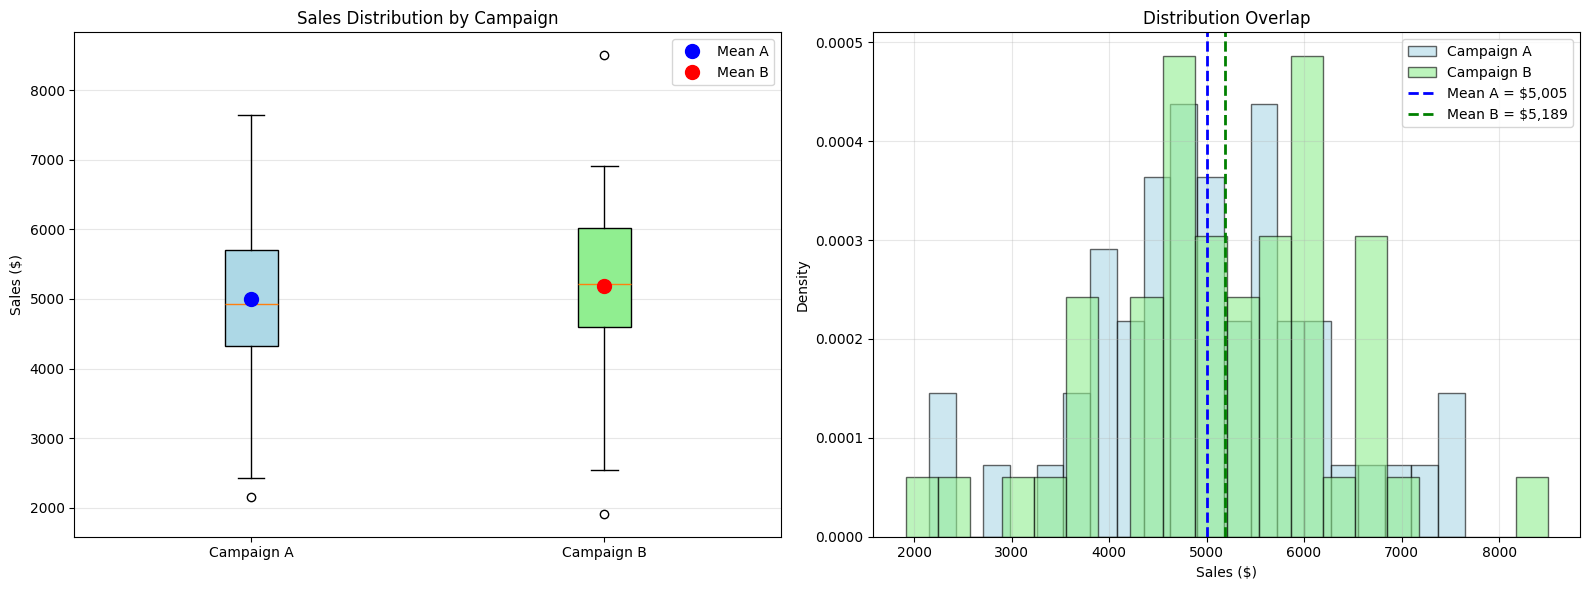

In [33]:
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

np.random.seed(99)
# Same mean (≈5000) for both campaigns — no real difference
camp_a_same = np.random.normal(5000, 1200, 50)
camp_b_same = np.random.normal(5050, 1200, 50)  # Only $50 difference

t_s, p_s = ttest_ind(camp_a_same, camp_b_same)

mean_a = np.mean(camp_a_same)
mean_b = np.mean(camp_b_same)
n_a = len(camp_a_same)
n_b = len(camp_b_same)
df_s = n_a + n_b - 2
t_crit_s = st.t.ppf(0.975, df_s)

print("Two-Sample T-Test: No Significant Difference scenario")
print("=" * 55)
print(f"Mean A: ${mean_a:,.2f}  |  Mean B: ${mean_b:,.2f}")
print(f"t-statistic: {t_s:.4f}")
print(f"p-value:     {p_s:.4f}")

if p_s < 0.05:
    print("\n✓ REJECT H₀ — significant difference found")
else:
    print("\n✗ FAIL TO REJECT H₀ — no significant difference between campaigns")
    print("   Business decision: Either campaign is acceptable")

# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Left: Boxplot ──
axes[0].set_facecolor('white')
bp = axes[0].boxplot(
    [camp_a_same, camp_b_same],
    tick_labels=['Campaign A', 'Campaign B'],
    patch_artist=True,
)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen']):
    patch.set_facecolor(color)
axes[0].set_ylabel('Sales ($)')
axes[0].set_title('Sales Distribution by Campaign')
axes[0].grid(axis='y', alpha=0.3)
axes[0].plot(1, mean_a, 'bo', markersize=10, label='Mean A', zorder=5)
axes[0].plot(2, mean_b, 'ro', markersize=10, label='Mean B', zorder=5)
axes[0].legend()

# ── Right: Overlapping distributions ──
axes[1].set_facecolor('white')
axes[1].hist(
    camp_a_same,
    bins=20,
    alpha=0.6,
    label='Campaign A',
    edgecolor='black',
    density=True,
    color='lightblue',
)
axes[1].hist(
    camp_b_same,
    bins=20,
    alpha=0.6,
    label='Campaign B',
    edgecolor='black',
    density=True,
    color='lightgreen',
)
axes[1].axvline(
    mean_a, color='blue', linestyle='--', linewidth=2, label=f'Mean A = ${mean_a:,.0f}'
)
axes[1].axvline(
    mean_b, color='green', linestyle='--', linewidth=2, label=f'Mean B = ${mean_b:,.0f}'
)
axes[1].set_xlabel('Sales ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution Overlap')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Reject H₀: New Model Significantly Outperforms Baseline Model</p>

Two classification models are trained and evaluated independently on 15 random train/test splits each. We want to test if Model B (a new architecture) significantly outperforms Model A (the current production model).

- **H₀:** μ_A = μ_B (same accuracy)
- **H₁:** μ_A ≠ μ_B
- **α = 0.05**

</div>


Two-Sample T-Test: ML Model A vs Model B (Independent Splits)
H₀: μ_A = μ_B   (same performance)
H₁: μ_A ≠ μ_B   (significantly different)

Model A — Mean F1: 0.8051, Std: 0.0302
Model B — Mean F1: 0.8612, Std: 0.0303

t-statistic: -5.0838
t-critical (df=28): ±2.0484
p-value: 0.000022

✓ REJECT H₀ (p < 0.05)
  Model B (86.12%) significantly outperforms
  Model A (80.51%) in F1 score.
  → Paper claim: Model B shows statistically significant improvement (p=0.0000).


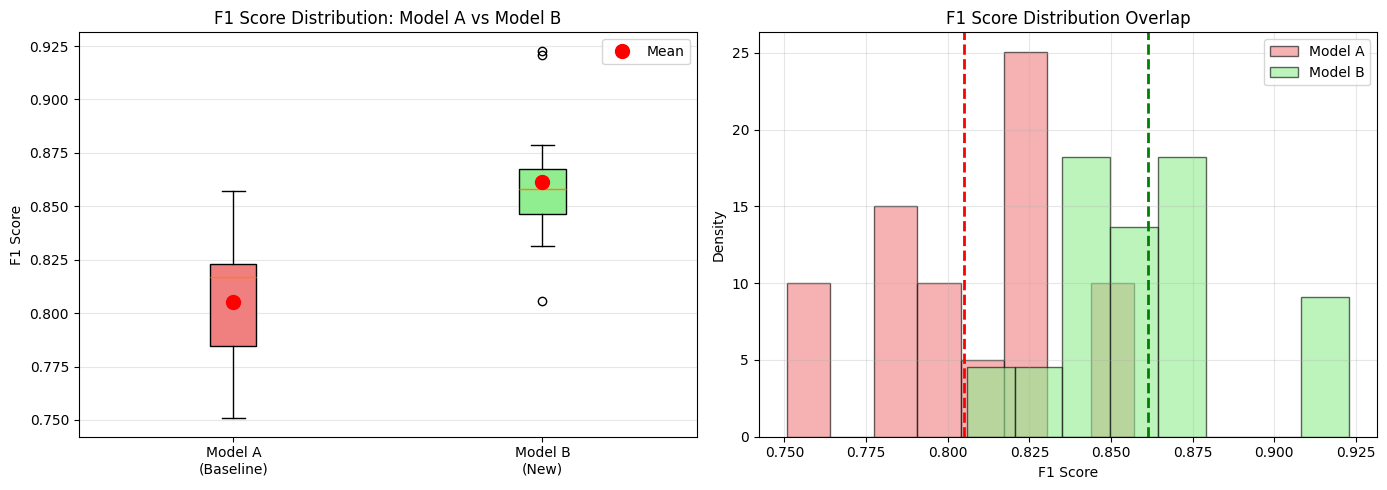

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy import stats

# Per-split F1 scores of two independently evaluated classification models
# Model A: current production model,  Model B: new architecture
np.random.seed(77)
f1_model_a = np.random.normal(0.81, 0.03, 15)  # mean F1 ≈ 0.81
f1_model_b = np.random.normal(0.87, 0.03, 15)  # mean F1 ≈ 0.87

# Two-sample t-test (independent: each model evaluated on different splits)
t_ml2, p_ml2 = ttest_ind(f1_model_a, f1_model_b)
df_ml2 = len(f1_model_a) + len(f1_model_b) - 2
t_crit_ml2 = stats.t.ppf(0.975, df_ml2)

print("Two-Sample T-Test: ML Model A vs Model B (Independent Splits)")
print("=" * 65)

print(f"H₀: μ_A = μ_B   (same performance)")
print(f"H₁: μ_A ≠ μ_B   (significantly different)")
print(
    f"\nModel A — Mean F1: {np.mean(f1_model_a):.4f}, Std: {np.std(f1_model_a, ddof=1):.4f}"  # Fix: removed "f\"\n    \" → f\"\n"
)
print(
    f"Model B — Mean F1: {np.mean(f1_model_b):.4f}, Std: {np.std(f1_model_b, ddof=1):.4f}"
)
print(f"\nt-statistic: {t_ml2:.4f}")
print(f"t-critical (df={df_ml2}): ±{t_crit_ml2:.4f}")
print(f"p-value: {p_ml2:.6f}")

if p_ml2 < 0.05:
    print(f"\n✓ REJECT H₀ (p < 0.05)")
    print(
        f"  Model B ({np.mean(f1_model_b):.2%}) significantly outperforms"
    )  # Fix: broken/garbled print
    print(f"  Model A ({np.mean(f1_model_a):.2%}) in F1 score.")
    print(
        f"  → Paper claim: Model B shows statistically significant improvement (p={p_ml2:.4f})."
    )

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

axes[0].set_facecolor('white')
bp = axes[0].boxplot(  # Fix: reconstructed garbled boxplot call
    [f1_model_a, f1_model_b],
    tick_labels=[
        'Model A\n(Baseline)',
        'Model B\n(New)',
    ],  # Fix: 'labels' → 'tick_labels', reconstructed broken strings
    patch_artist=True,
)
for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score Distribution: Model A vs Model B')
axes[0].plot(1, np.mean(f1_model_a), 'ro', markersize=10, zorder=5, label='Mean')
axes[0].plot(2, np.mean(f1_model_b), 'ro', markersize=10, zorder=5)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_facecolor('white')
axes[1].hist(
    f1_model_a,
    bins=8,
    alpha=0.6,
    color='lightcoral',
    edgecolor='black',
    density=True,
    label='Model A',
)
axes[1].hist(
    f1_model_b,
    bins=8,
    alpha=0.6,
    color='lightgreen',
    edgecolor='black',
    density=True,
    label='Model B',
)
axes[1].axvline(np.mean(f1_model_a), color='red', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(f1_model_b), color='green', linestyle='--', linewidth=2)
axes[1].set_xlabel('F1 Score')
axes[1].set_ylabel('Density')
axes[1].set_title('F1 Score Distribution Overlap')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `f1_model_a` and `f1_model_b` represent per-split F1 scores for two models evaluated **independently** (different random splits for each). This justifies using the independent two-sample t-test.
- `ttest_ind(f1_model_a, f1_model_b)` compares the two distributions of F1 scores.

**ML paper reporting format:**
> "Model B achieved a significantly higher mean F1 score (M=0.87, SD=0.03) compared to Model A (M=0.81, SD=0.03) across 15 independent evaluation splits (two-sample t-test: t(28)=XX, p<0.001, d=XX), supporting the superiority of the proposed architecture."

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Fail to Reject H₀: Two Feature Sets Yield No Significant Difference</p>

A regression model is trained on two different feature sets — original features vs. manually engineered features — each evaluated on 15 independent splits. We test if the engineered features significantly reduce RMSE.

- **H₀:** μ_RMSE_original = μ_RMSE_engineered
- **H₁:** μ_RMSE_original ≠ μ_RMSE_engineered
- **α = 0.05**

</div>


Two-Sample T-Test: Original vs Engineered Features (RMSE)
H₀: μ_RMSE_original = μ_RMSE_engineered
H₁: μ_RMSE_original ≠ μ_RMSE_engineered

Original features  — Mean RMSE: 5.2361,  Std: 0.4298
Engineered features — Mean RMSE: 5.0306,  Std: 0.4301

t-statistic: 1.3087
p-value: 0.2013

✗ FAIL TO REJECT H₀ (p = 0.2013 ≥ 0.05)
  Although engineered features show a slightly lower RMSE,
  the difference is NOT statistically significant.
  → Paper claim: Feature engineering did not yield statistically
    significant improvements in this setting (p=0.2013, n.s.).
  → Action: Revisit feature engineering strategy or increase sample size.


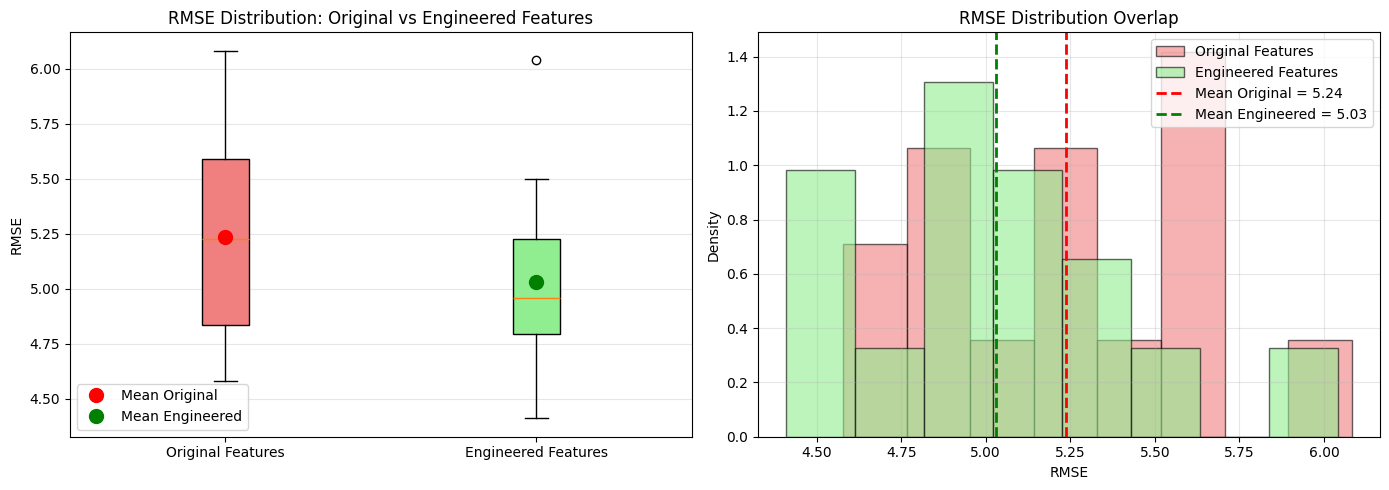

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# RMSE per split for a regression model: original vs engineered features
np.random.seed(88)
rmse_original = np.random.normal(5.20, 0.40, 15)  # mean RMSE ≈ 5.20
rmse_engineered = np.random.normal(5.05, 0.42, 15)  # mean RMSE ≈ 5.05 — slightly better

t_feat, p_feat = ttest_ind(rmse_original, rmse_engineered)

mean_original = np.mean(rmse_original)
mean_engineered = np.mean(rmse_engineered)

print("Two-Sample T-Test: Original vs Engineered Features (RMSE)")
print("=" * 60)
print(f"H₀: μ_RMSE_original = μ_RMSE_engineered")
print(f"H₁: μ_RMSE_original ≠ μ_RMSE_engineered")
print(
    f"\nOriginal features  — Mean RMSE: {mean_original:.4f},  Std: {np.std(rmse_original, ddof=1):.4f}"
)
print(
    f"Engineered features — Mean RMSE: {mean_engineered:.4f},  Std: {np.std(rmse_engineered, ddof=1):.4f}"
)
print(f"\nt-statistic: {t_feat:.4f}")
print(f"p-value: {p_feat:.4f}")

if p_feat < 0.05:
    print("\n✓ REJECT H₀ — engineered features significantly improve RMSE")
else:
    print(f"\n✗ FAIL TO REJECT H₀ (p = {p_feat:.4f} ≥ 0.05)")
    print(f"  Although engineered features show a slightly lower RMSE,")
    print(f"  the difference is NOT statistically significant.")
    print(f"  → Paper claim: Feature engineering did not yield statistically")
    print(f"    significant improvements in this setting (p={p_feat:.4f}, n.s.).")
    print(f"  → Action: Revisit feature engineering strategy or increase sample size.")

# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ── Left: Boxplot ──
axes[0].set_facecolor('white')
bp = axes[0].boxplot(
    [rmse_original, rmse_engineered],
    tick_labels=['Original Features', 'Engineered Features'],
    patch_artist=True,
)
for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Distribution: Original vs Engineered Features')
axes[0].grid(axis='y', alpha=0.3)
axes[0].plot(1, mean_original, 'ro', markersize=10, zorder=5, label='Mean Original')
axes[0].plot(2, mean_engineered, 'go', markersize=10, zorder=5, label='Mean Engineered')
axes[0].legend()

# ── Right: Overlapping distributions ──
axes[1].set_facecolor('white')
axes[1].hist(
    rmse_original,
    bins=8,
    alpha=0.6,
    label='Original Features',
    edgecolor='black',
    density=True,
    color='lightcoral',
)
axes[1].hist(
    rmse_engineered,
    bins=8,
    alpha=0.6,
    label='Engineered Features',
    edgecolor='black',
    density=True,
    color='lightgreen',
)
axes[1].axvline(
    mean_original,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean Original = {mean_original:.2f}',
)
axes[1].axvline(
    mean_engineered,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Mean Engineered = {mean_engineered:.2f}',
)
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Density')
axes[1].set_title('RMSE Distribution Overlap')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- The two RMSE distributions overlap heavily (std ≈ 0.40 vs mean difference ≈ 0.15), so the signal is buried in noise.
- The t-statistic is small → the difference between means is modest relative to the within-group variability.
- **In ML papers**, this result means the feature engineering effort did not produce a reliable, reproducible improvement. Reporting this honestly is important to avoid p-hacking.

**ML paper reporting format:**
> "The engineered feature set did not significantly reduce RMSE compared to the original features (M_orig=5.20 vs M_eng=5.05; two-sample t-test: t(28)=XX, p=0.XX, n.s.)."

</div>



<div style="max-width: 900px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 7.3 Paired T-Test

**When to use:** Compare means of the **same group** at two different times (before/after) or under two different conditions.

**Why paired?** Each "after" measurement is directly related to its "before" measurement for the **same individual**. It is essentially a one-sample t-test on the **differences** (d = after − before), testing whether the mean difference equals 0.

```
t = mean(d) / (s_d / √n)
```

Where `s_d` = standard deviation of the differences.

**Real-World Case: Training Program Effectiveness**

A company measures productivity for the **same 40 employees** before and after a training program.

- **H₀:** μ_diff = 0 → Training has no effect.
- **H₁:** μ_diff > 0 → Training improves productivity.
- **α = 0.05**, **df = n − 1 = 39**

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Using Paired T-Test in ML Research Papers</p>

The paired t-test is the **gold standard for comparing two ML models** when both are evaluated on the **same** cross-validation folds. Since both models see the same data in each fold, the fold-level scores are inherently paired — controlling for dataset difficulty.

**Classification research:**

Two classifiers (Model A and Model B) are evaluated on the **same 10 folds**. The per-fold accuracy difference (accuracy_B[i] − accuracy_A[i]) captures pure model effect, with data-split variance cancelled out.

- **H₀:** μ_diff = 0 (no systematic advantage of B over A)
- **H₁:** μ_diff > 0 (Model B is consistently better across folds)
- `ttest_rel(accuracy_B, accuracy_A)` — more powerful than two-sample test

**Regression research:**

Two regression algorithms are compared on the same 10 folds. The RMSE difference per fold captures which algorithm consistently performs better, independent of the fold's difficulty.

> **Why paired beats two-sample here:** If fold 3 has particularly hard samples, both models will do worse on fold 3. The paired test controls for this, leaving only the true model difference. The two-sample test would attribute fold difficulty to model variance — making it harder to detect real differences.

**Reference in literature:**

Dietterich (1998) recommends the 5×2 cross-validation paired t-test as the most reliable method for comparing two ML algorithms. This design uses 5 repetitions of 2-fold CV and applies a paired t-test on the resulting differences.

</div>


Paired T-Test: Training Program Effectiveness
H₀: μ_diff = 0  (training has no effect)
H₁: μ_diff > 0  (training improves productivity)

Sample size: 40 employees
Mean before:     72.81
Mean after:      80.67
Mean improvement:7.85 points
Std dev of diff: 4.82

Test Results:
  t-statistic: 10.2984
  t-critical (df=39): ±2.0227
  p-value: 0.0000
  95% CI for improvement: [6.31, 9.40]

✓ REJECT H₀ (p < 0.05): Training significantly improves productivity
  Recommendation: Implement training company-wide

Cost-Benefit Analysis:
  Training cost: $2,000/employee
  Expected annual benefit: $7,855/employee
  ROI: 292.7%


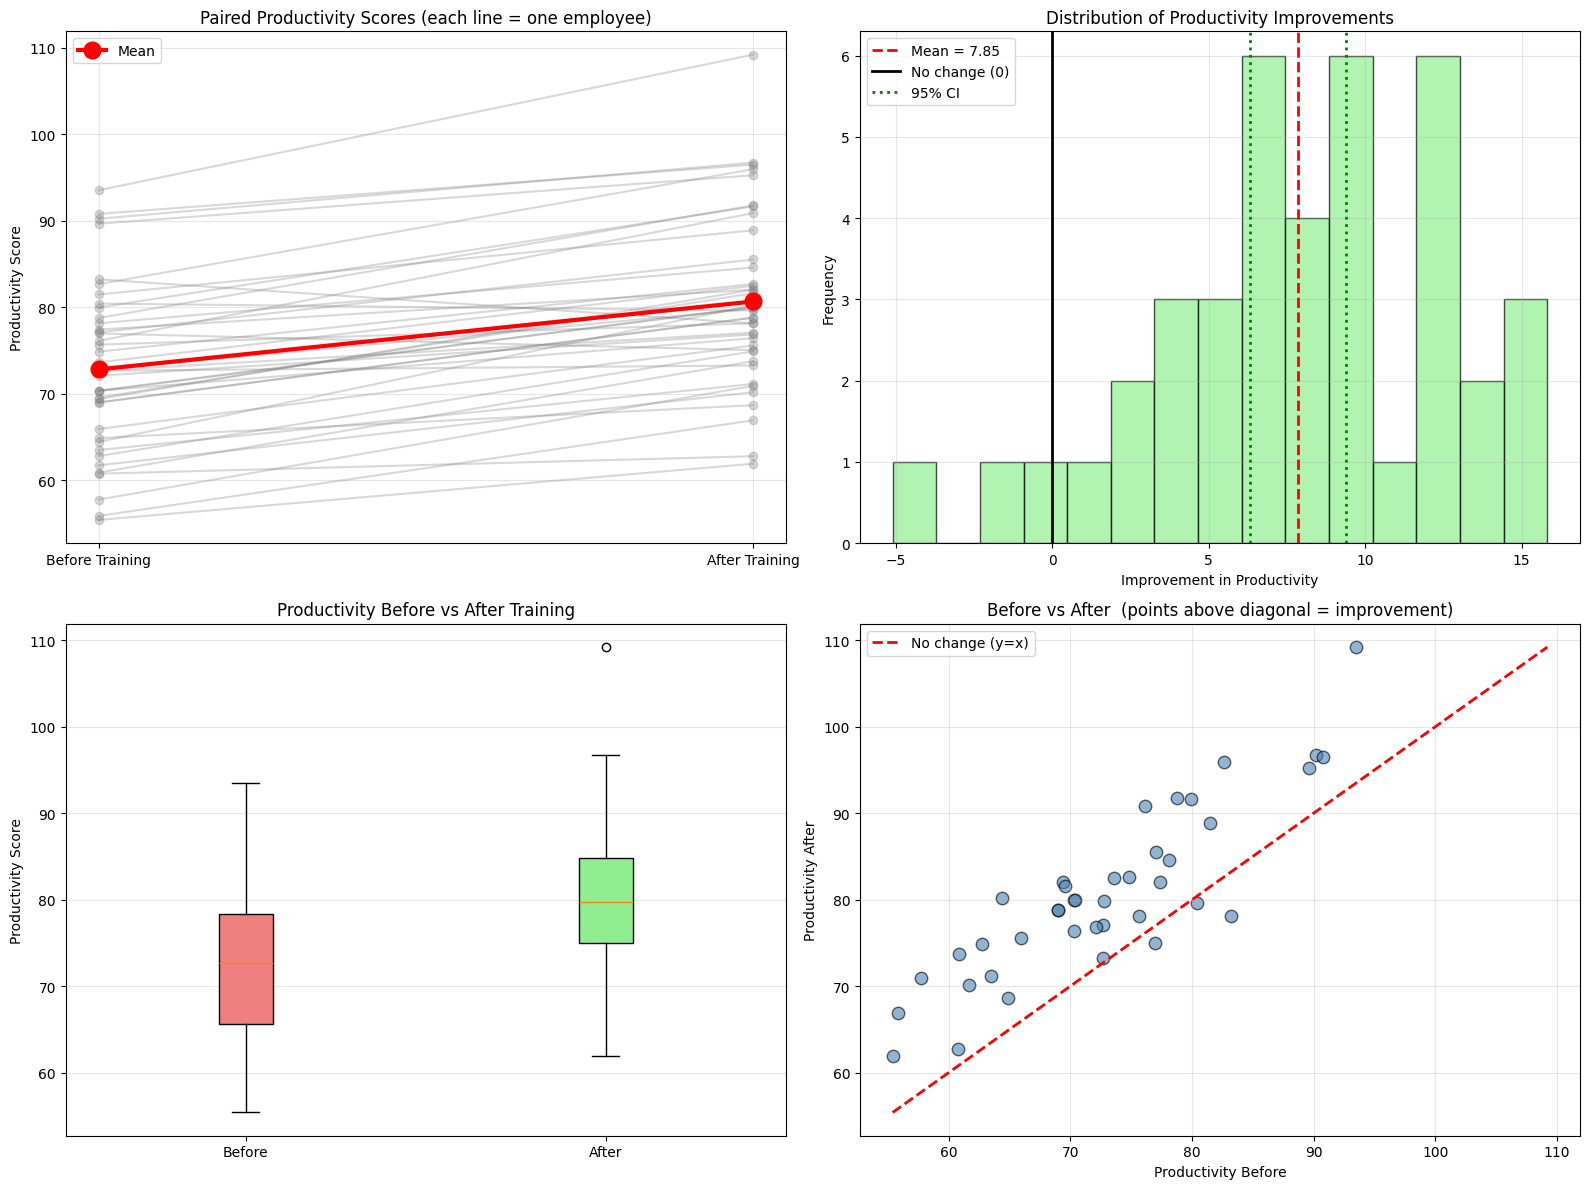

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_rel

# ── Step 1: Generate synthetic paired data ────────────────────────────────
np.random.seed(42)
n_employees = 40

# Productivity before training (mean ≈75, std dev ≈10)
productivity_before = np.random.normal(75, 10, n_employees)
# After training: +8 points on average, with individual noise
productivity_after = productivity_before + np.random.normal(8, 5, n_employees)

# ── Step 2: Perform paired t-test ────────────────────────────────────────
t_stat, p_value = ttest_rel(productivity_after, productivity_before)

# ── Step 3: Statistics of the differences ────────────────────────────────
improvement = productivity_after - productivity_before
mean_improvement = np.mean(improvement)
std_improvement = np.std(improvement, ddof=1)
se_improvement = std_improvement / np.sqrt(n_employees)

df_p = n_employees - 1
t_crit_p = stats.t.ppf(0.975, df_p)
ci_lower_p = mean_improvement - t_crit_p * se_improvement
ci_upper_p = mean_improvement + t_crit_p * se_improvement

print("Paired T-Test: Training Program Effectiveness")
print("=" * 60)
print(f"H₀: μ_diff = 0  (training has no effect)")
print(f"H₁: μ_diff > 0  (training improves productivity)")
print(f"\nSample size: {n_employees} employees")
print(f"Mean before:     {np.mean(productivity_before):.2f}")
print(f"Mean after:      {np.mean(productivity_after):.2f}")
print(f"Mean improvement:{mean_improvement:.2f} points")
print(f"Std dev of diff: {std_improvement:.2f}")
print(f"\nTest Results:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  t-critical (df={df_p}): ±{t_crit_p:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  95% CI for improvement: [{ci_lower_p:.2f}, {ci_upper_p:.2f}]")

alpha = 0.05
if p_value < alpha:
    print(f"\n✓ REJECT H₀ (p < {alpha}): Training significantly improves productivity")
    print(f"  Recommendation: Implement training company-wide")
else:
    print(f"\n✗ FAIL TO REJECT H₀: No significant evidence of training effectiveness")

# ── Step 5: Cost-benefit analysis ────────────────────────────────────────
training_cost = 2000
annual_value_pt = 1000
annual_benefit = mean_improvement * annual_value_pt
roi_pct = (annual_benefit - training_cost) / training_cost * 100
print(f"\nCost-Benefit Analysis:")
print(f"  Training cost: ${training_cost:,.0f}/employee")
print(f"  Expected annual benefit: ${annual_benefit:,.0f}/employee")
print(f"  ROI: {roi_pct:.1f}%")

# ── Step 6: Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

# ── Plot 1: Paired before vs after ──
for b, a in zip(productivity_before, productivity_after):
    axes[0, 0].plot([0, 1], [b, a], 'o-', alpha=0.3, color='gray')

axes[0, 0].plot(
    [0, 1],
    [np.mean(productivity_before), np.mean(productivity_after)],
    'ro-',
    linewidth=3,
    markersize=12,
    label='Mean',
)
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Before Training', 'After Training'])
axes[0, 0].set_ylabel('Productivity Score')
axes[0, 0].set_title('Paired Productivity Scores (each line = one employee)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── Plot 2: Distribution of improvements ──
axes[0, 1].hist(improvement, bins=15, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].axvline(
    mean_improvement,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_improvement:.2f}',
)
axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=2, label='No change (0)')
axes[0, 1].axvline(
    ci_lower_p, color='green', linestyle=':', linewidth=2, label='95% CI'
)
axes[0, 1].axvline(ci_upper_p, color='green', linestyle=':', linewidth=2)
axes[0, 1].set_xlabel('Improvement in Productivity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Productivity Improvements')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Plot 3: Boxplot comparison ──
bp = axes[1, 0].boxplot(
    [productivity_before, productivity_after],
    tick_labels=['Before', 'After'],
    patch_artist=True,
)
for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
axes[1, 0].set_ylabel('Productivity Score')
axes[1, 0].set_title('Productivity Before vs After Training')
axes[1, 0].grid(axis='y', alpha=0.3)

# ── Plot 4: Scatter before vs after ──
axes[1, 1].scatter(
    productivity_before,
    productivity_after,
    alpha=0.6,
    s=80,
    edgecolors='black',
    color='steelblue',
)
lo = min(productivity_before.min(), productivity_after.min())
hi = max(productivity_before.max(), productivity_after.max())
axes[1, 1].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='No change (y=x)')
axes[1, 1].set_xlabel('Productivity Before')
axes[1, 1].set_ylabel('Productivity After')
axes[1, 1].set_title('Before vs After  (points above diagonal = improvement)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `ttest_rel(a, b)` – paired (related-samples) t-test.
  - `a` and `b` must have the **same length** (one measurement per individual in each condition).
  - Internally computes `d = a − b` and tests if `mean(d) == 0`.
  - Returns `(t_statistic, p_value)`.
- **df = n − 1** (not n₁ + n₂ − 2 like the two-sample test) because we only have one group of differences.

**Plot interpretations:**
- **Paired line plot (top-left):** Each gray line = one employee. Mostly upward-sloping lines confirm training helped. The red line shows the mean trajectory.
- **Histogram of improvements (top-right):** Almost all values are above 0 → training helped nearly everyone. The CI doesn't include 0 → statistically significant.
- **Scatter plot (bottom-right):** Points above the red diagonal (y=x) line indicate improvement. The cluster above the line confirms the positive effect.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Example: Fail to Reject H₀ (Training shows no significant effect)</p>

</div>


In [37]:
from scipy.stats import ttest_rel
import numpy as np

np.random.seed(55)
n = 40
before = np.random.normal(75, 10, n)
# After: only +0.5 points on average — essentially no effect
after = before + np.random.normal(0.5, 5, n)

t_s_paired, p_s_paired = ttest_rel(after, before)
print("Paired T-Test: No Significant Improvement scenario")
print("=" * 50)
print(f"Mean before: {np.mean(before):.2f} | Mean after: {np.mean(after):.2f}")
print(f"Mean diff:   {np.mean(after - before):.2f}")
print(f"t-statistic: {t_s_paired:.4f}")
print(f"p-value:     {p_s_paired:.4f}")

if p_s_paired < 0.05:
    print("\n✓ REJECT H₀ — training works!")
else:
    print("\n✗ FAIL TO REJECT H₀ — no significant improvement detected")
    print("   Recommendation: Re-evaluate training program")

Paired T-Test: No Significant Improvement scenario
Mean before: 74.94 | Mean after: 75.80
Mean diff:   0.86
t-statistic: 1.1599
p-value:     0.2531

✗ FAIL TO REJECT H₀ — no significant improvement detected
   Recommendation: Re-evaluate training program



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Reject H₀: Model B Significantly Outperforms Model A on Same Folds</p>

Two classification models are evaluated on the **exact same 10 cross-validation folds**. Since the same data partitions are used, the per-fold scores are paired observations.

- **H₀:** μ_diff = 0 (no systematic difference between models)
- **H₁:** μ_diff ≠ 0 (Model B consistently differs from Model A)
- **α = 0.05**

</div>


Paired T-Test: Same-Fold Comparison of Two Classifiers
H₀: μ_diff = 0  (no systematic difference)
H₁: μ_diff ≠ 0  (Model B consistently differs from Model A)

Fold-level accuracy differences (B - A):
  Fold  1: B=0.8686  A=0.8120  Δ=+0.0566
  Fold  2: B=0.8304  A=0.7799  Δ=+0.0504
  Fold  3: B=0.8414  A=0.7816  Δ=+0.0598
  Fold  4: B=0.8814  A=0.8057  Δ=+0.0757
  Fold  5: B=0.8583  A=0.8146  Δ=+0.0437
  Fold  6: B=0.8533  A=0.8264  Δ=+0.0269
  Fold  7: B=0.8620  A=0.8163  Δ=+0.0457
  Fold  8: B=0.9428  A=0.8703  Δ=+0.0725
  Fold  9: B=0.8626  A=0.8176  Δ=+0.0450
  Fold 10: B=0.8957  A=0.8306  Δ=+0.0652

Mean accuracy Model A: 0.8155
Mean accuracy Model B: 0.8696
Mean difference (B-A): +0.0541
95% CI for difference: [0.0435, 0.0648]

t-statistic: 11.5532
t-critical (df=9): ±2.2622
p-value: 0.000001

✓ REJECT H₀ (p < 0.05)
  Model B is consistently and significantly better than Model A
  across all 10 evaluation folds.
  The improvement CI [0.0435, 0.0648] lies entirely above 0.
  → Pape

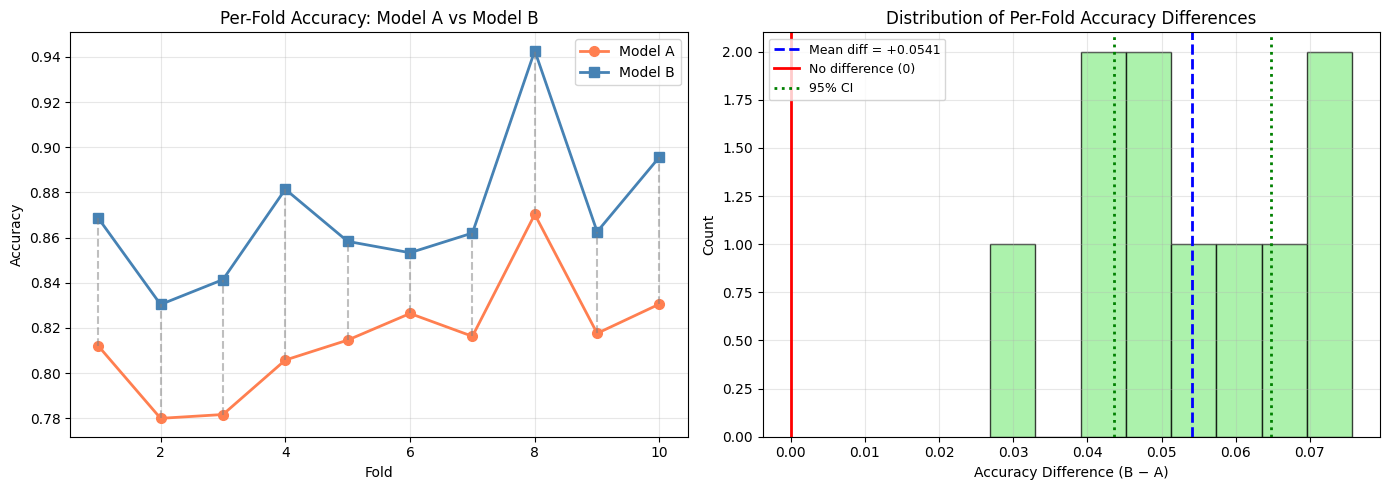

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy import stats

np.random.seed(33)

# Per-fold accuracy of two classifiers on the SAME 10 folds
# Because both models use the same folds, scores are paired
# Model A: current model, fold accuracies
accuracy_model_a = np.random.normal(0.82, 0.025, 10)
# Model B: new model, evaluated on the same folds (higher by ~0.06 per fold)
accuracy_model_b = accuracy_model_a + np.random.normal(0.060, 0.015, 10)

# Paired t-test — tests if mean(model_b - model_a) == 0
t_paired_ml, p_paired_ml = ttest_rel(accuracy_model_b, accuracy_model_a)

# Per-fold differences
diff = accuracy_model_b - accuracy_model_a
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)
n_folds = len(diff)
df_paired = n_folds - 1
t_crit_p = stats.t.ppf(0.975, df_paired)
ci_lo_p = mean_diff - t_crit_p * (std_diff / np.sqrt(n_folds))
ci_hi_p = mean_diff + t_crit_p * (std_diff / np.sqrt(n_folds))

print("Paired T-Test: Same-Fold Comparison of Two Classifiers")
print("=" * 65)
print(f"H₀: μ_diff = 0  (no systematic difference)")
print(f"H₁: μ_diff ≠ 0  (Model B consistently differs from Model A)")
print(f"\nFold-level accuracy differences (B - A):")
for i, d in enumerate(diff, 1):
    print(
        f"  Fold {i:2d}: B={accuracy_model_b[i-1]:.4f}  A={accuracy_model_a[i-1]:.4f}  Δ={d:+.4f}"
    )
print(f"\nMean accuracy Model A: {np.mean(accuracy_model_a):.4f}")
print(f"Mean accuracy Model B: {np.mean(accuracy_model_b):.4f}")
print(f"Mean difference (B-A): {mean_diff:+.4f}")
print(f"95% CI for difference: [{ci_lo_p:.4f}, {ci_hi_p:.4f}]")
print(f"\nt-statistic: {t_paired_ml:.4f}")
print(f"t-critical (df={df_paired}): ±{t_crit_p:.4f}")
print(f"p-value: {p_paired_ml:.6f}")

if p_paired_ml < 0.05:
    print(f"\n✓ REJECT H₀ (p < 0.05)")
    print(f"  Model B is consistently and significantly better than Model A")
    print(f"  across all {n_folds} evaluation folds.")
    print(f"  The improvement CI [{ci_lo_p:.4f}, {ci_hi_p:.4f}] lies entirely above 0.")
    print(f"  → Paper claim: Proposed model significantly outperforms baseline")
    print(
        f"    (paired t-test: t({df_paired})={t_paired_ml:.2f}, p={p_paired_ml:.4f})."
    )

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# Left: fold comparison
axes[0].plot(
    range(1, 11),
    accuracy_model_a,
    'o-',
    color='coral',
    linewidth=2,
    markersize=7,
    label='Model A',
)
axes[0].plot(
    range(1, 11),
    accuracy_model_b,
    's-',
    color='steelblue',
    linewidth=2,
    markersize=7,
    label='Model B',
)
for i in range(n_folds):
    axes[0].plot(
        [i + 1, i + 1],
        [accuracy_model_a[i], accuracy_model_b[i]],
        'gray',
        alpha=0.5,
        linestyle='--',
    )
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Per-Fold Accuracy: Model A vs Model B')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: distribution of differences
axes[1].hist(diff, bins=8, edgecolor='black', alpha=0.75, color='lightgreen')
axes[1].axvline(
    mean_diff,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean diff = {mean_diff:+.4f}',
)
axes[1].axvline(0, color='red', linestyle='-', linewidth=2, label='No difference (0)')
axes[1].axvline(ci_lo_p, color='green', linestyle=':', linewidth=2, label='95% CI')
axes[1].axvline(ci_hi_p, color='green', linestyle=':', linewidth=2)
axes[1].set_xlabel('Accuracy Difference (B − A)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Per-Fold Accuracy Differences')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- Each element of `accuracy_model_a[i]` and `accuracy_model_b[i]` represents both models' performance on the **same fold i**. This makes them paired observations.
- `ttest_rel(accuracy_model_b, accuracy_model_a)` internally computes `diff = b - a` per fold and tests if `mean(diff) == 0`.
- The per-fold comparison plot (left) shows each fold connected by a gray line — almost all lines slope upward (Model B consistently better).
- The CI for the difference lies entirely above 0 → strong, consistent evidence that Model B is better.

**Why use paired instead of two-sample?** If we used `ttest_ind`, we'd lose the pairing information and dilute the signal with fold-level noise. The paired test has more statistical **power** to detect real differences.

</div>



<div style="max-width: 1000px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Fail to Reject H₀: No Consistent Improvement Across Folds</p>

Two regression models are evaluated on the same 10 folds. Model B uses a slightly more complex architecture. The improvements are inconsistent across folds.

- **H₀:** μ_diff = 0 (no systematic RMSE reduction)
- **H₁:** μ_diff ≠ 0
- **α = 0.05**

</div>


Paired T-Test: Regression Model A vs Model B (Same Folds, RMSE)
H₀: μ_diff = 0  (no consistent improvement)
H₁: μ_diff ≠ 0

Fold-level RMSE differences (A - B):
  Fold  1: A=5.2955  B=6.1325  Δ=-0.8371
  Fold  2: A=4.4201  B=4.6980  Δ=-0.2778
  Fold  3: A=4.5843  B=4.8855  Δ=-0.3013
  Fold  4: A=4.5351  B=4.9156  Δ=-0.3806
  Fold  5: A=4.9215  B=4.8172  Δ=+0.1043
  Fold  6: A=5.3448  B=5.2780  Δ=+0.0668
  Fold  7: A=3.7653  B=3.6598  Δ=+0.1055
  Fold  8: A=5.2757  B=5.0424  Δ=+0.2333
  Fold  9: A=5.0269  B=4.9623  Δ=+0.0646
  Fold 10: A=4.9001  B=4.6603  Δ=+0.2398

Mean RMSE Model A: 4.8069
Mean RMSE Model B: 4.9052
Mean difference (A-B): -0.0982
95% CI for difference: [-0.3437, 0.1472]

t-statistic: -0.9054
t-critical (df=9): ±2.2622
p-value: 0.3888

✗ FAIL TO REJECT H₀ (p = 0.3888 ≥ 0.05)
  Model B shows no consistent RMSE improvement over Model A.
  Differences vary across folds — no systematic advantage.
  → Paper claim: The architectural change did not yield statistically
    sign

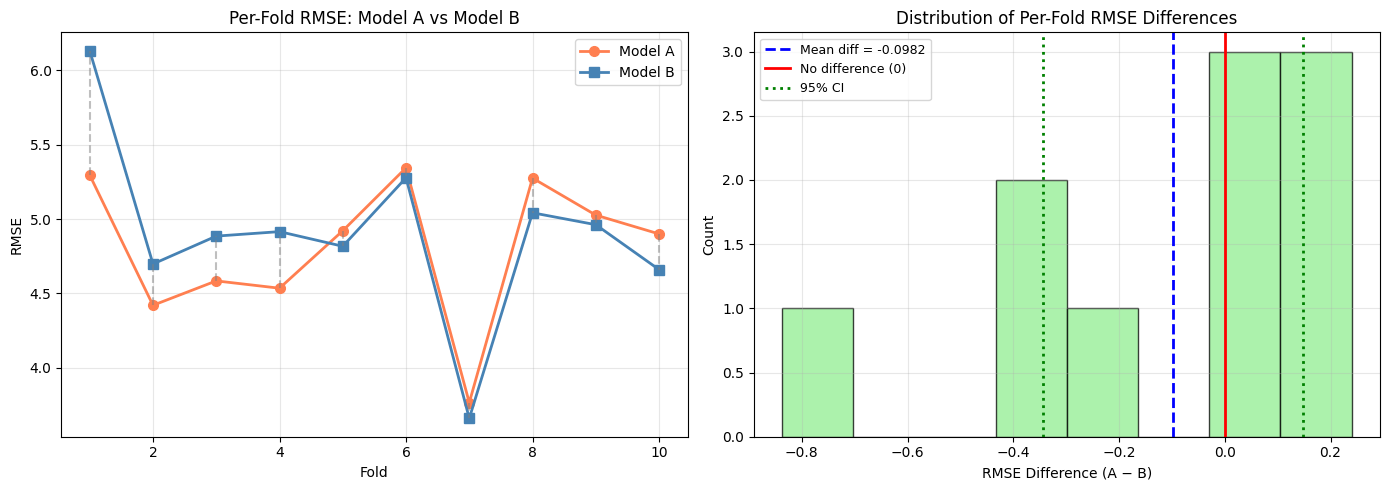

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy import stats

# Seed for reproducibility
np.random.seed(66)

# Simulate per-fold RMSE for Model A across 10 folds
# Lower RMSE = better performance
rmse_a = np.random.normal(4.80, 0.35, 10)

# Model B: same folds, small random shift around -0.05
# No guaranteed improvement — sometimes better, sometimes worse
rmse_b = rmse_a + np.random.normal(-0.05, 0.30, 10)

# --- Paired T-Test ---
# ttest_rel tests if mean(rmse_a - rmse_b) == 0
# Paired because both models are evaluated on the SAME folds
t_p_ml2, p_p_ml2 = ttest_rel(rmse_a, rmse_b)

# Per-fold differences: positive = Model A has higher RMSE (Model B better that fold)
diff_reg = rmse_a - rmse_b

# --- Manual CI Calculation ---
mean_diff = np.mean(diff_reg)  # average difference across folds
std_diff = np.std(diff_reg, ddof=1)  # sample std (ddof=1 for unbiased)
n_folds = len(diff_reg)  # number of folds = 10
df_paired = n_folds - 1  # degrees of freedom = 9

# Critical t-value for 95% CI (two-tailed) → use α/2 = 0.025 in ppf
t_crit_p = stats.t.ppf(0.975, df_paired)

# 95% confidence interval: mean ± t_crit * standard error
ci_lo = mean_diff - t_crit_p * (std_diff / np.sqrt(n_folds))
ci_hi = mean_diff + t_crit_p * (std_diff / np.sqrt(n_folds))

# --- Print Results ---
print("Paired T-Test: Regression Model A vs Model B (Same Folds, RMSE)")
print("=" * 65)
print(f"H₀: μ_diff = 0  (no consistent improvement)")
print(f"H₁: μ_diff ≠ 0")
print(f"\nFold-level RMSE differences (A - B):")
for i, d in enumerate(diff_reg, 1):
    print(f"  Fold {i:2d}: A={rmse_a[i-1]:.4f}  B={rmse_b[i-1]:.4f}  Δ={d:+.4f}")
print(f"\nMean RMSE Model A: {np.mean(rmse_a):.4f}")
print(f"Mean RMSE Model B: {np.mean(rmse_b):.4f}")
print(f"Mean difference (A-B): {mean_diff:+.4f}")
print(f"95% CI for difference: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"\nt-statistic: {t_p_ml2:.4f}")
print(f"t-critical (df={df_paired}): ±{t_crit_p:.4f}")
print(f"p-value: {p_p_ml2:.4f}")

# --- Decision Rule ---
# Compare p-value directly with α = 0.05 (never α/2)
if p_p_ml2 < 0.05:
    print("\n✓ REJECT H₀ — consistent improvement detected")
else:
    # CI crossing zero also confirms no significant difference
    print(f"\n✗ FAIL TO REJECT H₀ (p = {p_p_ml2:.4f} ≥ 0.05)")
    print(f"  Model B shows no consistent RMSE improvement over Model A.")
    print(f"  Differences vary across folds — no systematic advantage.")
    print(f"  → Paper claim: The architectural change did not yield statistically")
    print(
        f"    significant improvements (paired t-test: t(9)={t_p_ml2:.2f}, p={p_p_ml2:.4f})."
    )
    print(f"  → Action: The added complexity of Model B is not justified by the data.")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# Left plot: per-fold RMSE for both models
# Dashed vertical lines connect paired observations fold-by-fold
axes[0].plot(
    range(1, 11),
    rmse_a,
    'o-',
    color='coral',
    linewidth=2,
    markersize=7,
    label='Model A',
)
axes[0].plot(
    range(1, 11),
    rmse_b,
    's-',
    color='steelblue',
    linewidth=2,
    markersize=7,
    label='Model B',
)
for i in range(n_folds):
    # Gray connector shows the paired difference on each fold
    axes[0].plot(
        [i + 1, i + 1], [rmse_a[i], rmse_b[i]], 'gray', alpha=0.5, linestyle='--'
    )
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Per-Fold RMSE: Model A vs Model B')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: histogram of fold-level differences (A - B)
# If H₀ is true, this distribution should be centered near 0
axes[1].hist(diff_reg, bins=8, edgecolor='black', alpha=0.75, color='lightgreen')

# Mean difference line — should be close to 0 if no improvement
axes[1].axvline(
    mean_diff,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean diff = {mean_diff:+.4f}',
)

# Zero line — represents H₀ (no difference)
axes[1].axvline(0, color='red', linestyle='-', linewidth=2, label='No difference (0)')

# CI bounds — if CI crosses 0, we fail to reject H₀
axes[1].axvline(ci_lo, color='green', linestyle=':', linewidth=2, label='95% CI')
axes[1].axvline(ci_hi, color='green', linestyle=':', linewidth=2)
axes[1].set_xlabel('RMSE Difference (A − B)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Per-Fold RMSE Differences')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- The per-fold differences fluctuate around 0 with no consistent direction — sometimes Model A wins, sometimes Model B wins.
- The standard deviation of differences is large relative to the mean difference → p-value is large → fail to reject H₀.
- **Practical ML insight:** A more complex model that does not significantly improve performance is not worth the added computational cost, risk of overfitting, or deployment complexity. 
</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 8. Chi-Square Tests

**Chi-Square tests** work with **categorical data** — counts and frequencies. They answer questions like "is the observed distribution what we expected?" or "are two categorical variables related?"

The chi-square statistic measures how far observed counts deviate from expected counts:

```
χ² = Σ [(O − E)² / E]
```

Where:
- `O` = Observed frequency
- `E` = Expected frequency
- Sum is over all categories/cells

**Key properties:**
- χ² is always **non-negative** (≥ 0).
- χ² = 0 means perfect match between observed and expected.
- Larger χ² → more evidence against H₀.
- The χ² distribution is **right-skewed** (one-tailed rejection region on the right).

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 8.1 Chi-Square Goodness of Fit Test

**Purpose:** Tests whether a single categorical variable follows an expected/hypothesized distribution.

**Real-World Case: Website Traffic Distribution**

A website expects **equal traffic** across all days of the week. We test if observed traffic matches this expectation.

- **H₀:** Traffic is equally distributed across all days.
- **H₁:** Traffic is NOT equally distributed.
- **α = 0.05**, **df = k − 1 = 6** (k = number of categories = 7 days)

<p style="color: steelblue; font-size: 1.5em;">Reading the Chi-Square Table</p>

To find χ²_critical from the table:
1. Determine **df = k − 1** (k = number of categories).
2. Find the **α column** (e.g., 0.05).
3. Intersection of df row and α column = critical value.
4. For df = 6, α = 0.05: **χ²_critical = 12.59**

If **χ²_statistic > χ²_critical** → Reject H₀. Equivalently, if **p-value < α** → Reject H₀.

**Observed vs Expected (Total = 1,320 visitors):**

| Day | Observed | Expected (= 1320/7) |
|-----|----------|---------------------|
| Mon | 177 | 188.57 |
| Tue | 167 | 188.57 |
| Wed | 179 | 188.57 |
| Thu | 192 | 188.57 |
| Fri | 166 | 188.57 |
| Sat | 206 | 188.57 |
| Sun | 233 | 188.57 |

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Using Chi-Square Goodness of Fit in ML Research Papers</p>

In ML, the chi-square goodness of fit test is used to verify whether the **distribution of a model's outputs or errors** matches a theoretical or expected distribution.

**Classification research — class balance check:**

Before training, you check whether the model's predicted class distribution matches the ground truth class distribution. If a classifier predicts 90% class 0 and 10% class 1 but the true distribution is 50/50, it's performing poorly in a non-obvious way.

- **H₀:** Predicted class distribution matches the true distribution.
- **H₁:** They differ significantly.

**Regression research — residual distribution check:**

A core assumption of many regression models is that residuals (prediction errors) follow a **uniform or symmetric distribution** (no systematic bias). You can use a chi-square goodness of fit to check whether residual bins follow a uniform distribution.

- **H₀:** Residuals are uniformly distributed across bins (no systematic bias).
- **H₁:** Residuals are not uniformly distributed (model has systematic bias).

**Data drift detection in deployment:**

After deploying a model, you compare the distribution of incoming feature values against the training distribution. A significant chi-square test signals **data drift** — the real-world data no longer looks like the training data.

- **H₀:** Live data follows the same distribution as training data.
- **H₁:** Distribution has shifted (model retraining needed).

</div>


Chi-Square Goodness of Fit: Weekly Traffic Distribution
H₀: Traffic is equally distributed across all days
H₁: Traffic is NOT equally distributed

Total visitors: 1,320

Day       Observed    Expected        Diff
---------------------------------------------
Mon            177      188.57      -11.57
Tue            167      188.57      -21.57
Wed            179      188.57       -9.57
Thu            192      188.57       +3.43
Fri            166      188.57      -22.57
Sat            206      188.57      +17.43
Sun            233      188.57      +44.43

Test Results:
  χ² statistic: 18.5061
  Critical value (df=6, α=0.05): 12.59
  Degrees of freedom: 6
  p-value: 0.0051

✓ REJECT H₀ (p < 0.05): Traffic is NOT equally distributed
  Business insight: Weekend traffic is significantly higher
  Recommendation: Allocate more server resources for weekends


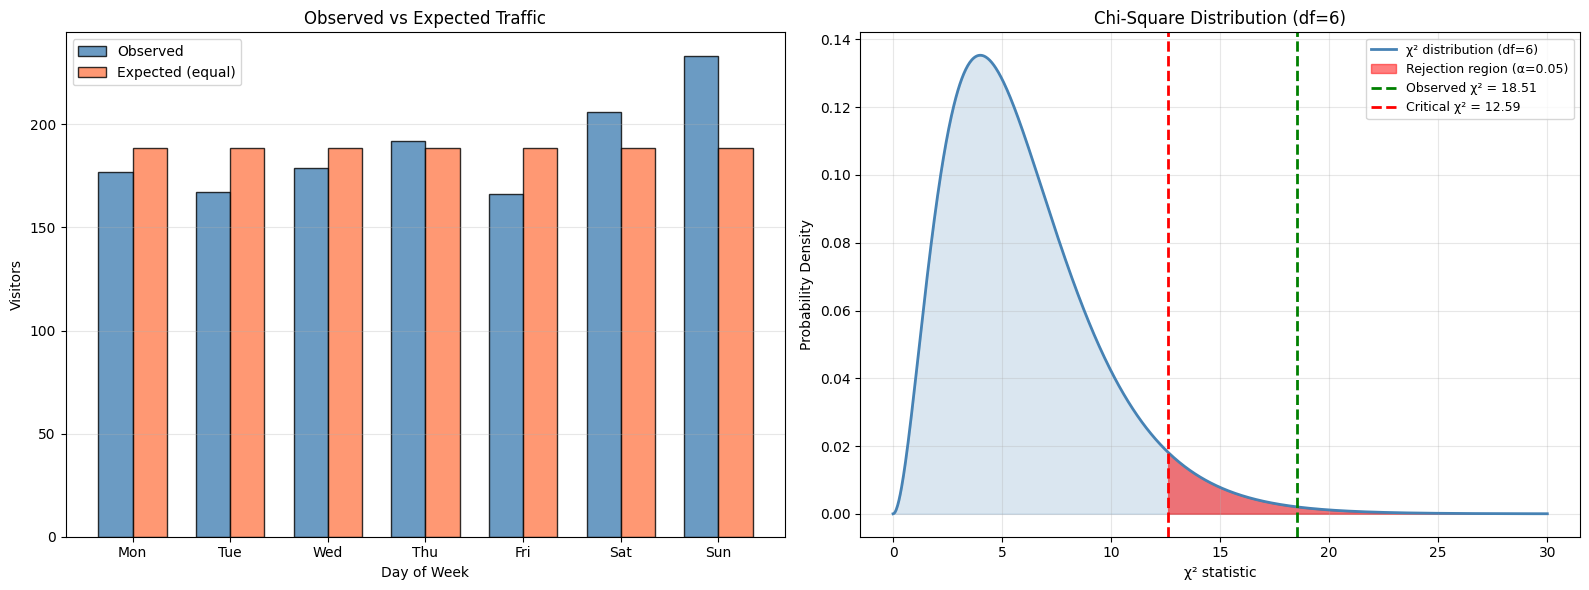

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chisquare

# ── Step 1: Generate synthetic observed traffic ───────────────────────────
np.random.seed(42)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
base_mean = 170
base_std = 15

# Weekday traffic (Mon-Fri)
weekday_traffic = np.random.normal(base_mean, base_std, 5).astype(int)
# Weekend traffic higher (Sat-Sun)
weekend_traffic = np.random.normal(base_mean + 40, base_std, 2).astype(int)
observed = np.concatenate([weekday_traffic, weekend_traffic])
total_visitors = observed.sum()

# ── Step 2: Expected frequencies (equal distribution) ────────────────────
expected = np.array([total_visitors / 7] * 7)

# ── Step 3: Chi-square goodness of fit test ───────────────────────────────
chi2_stat, p_value = chisquare(observed, expected)

print("Chi-Square Goodness of Fit: Weekly Traffic Distribution")
print("=" * 60)
print(f"H₀: Traffic is equally distributed across all days")
print(f"H₁: Traffic is NOT equally distributed")
print(f"\nTotal visitors: {total_visitors:,}")
print(f"\n{'Day':6s}  {'Observed':>10}  {'Expected':>10}  {'Diff':>10}")
print("-" * 45)
for day, obs, exp in zip(days, observed, expected):
    print(f"{day:6s}  {obs:>10.0f}  {exp:>10.2f}  {obs-exp:>+10.2f}")

df_chi = len(days) - 1
critical_v = stats.chi2.ppf(0.95, df_chi)

print(f"\nTest Results:")
print(f"  χ² statistic: {chi2_stat:.4f}")
print(f"  Critical value (df={df_chi}, α=0.05): {critical_v:.2f}")
print(f"  Degrees of freedom: {df_chi}")
print(f"  p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✓ REJECT H₀ (p < {alpha}): Traffic is NOT equally distributed")
    print(f"  Business insight: Weekend traffic is significantly higher")
    print(f"  Recommendation: Allocate more server resources for weekends")
else:
    print(f"\n✗ FAIL TO REJECT H₀: Traffic consistent with equal distribution")

# ── Step 5: Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Left: Observed vs Expected bar chart ──
axes[0].set_facecolor('white')
x = np.arange(len(days))
width = 0.35
axes[0].bar(
    x - width / 2,
    observed,
    width,
    label='Observed',
    alpha=0.8,
    edgecolor='black',
    color='steelblue',
)
axes[0].bar(
    x + width / 2,
    expected,
    width,
    label='Expected (equal)',
    alpha=0.8,
    edgecolor='black',
    color='coral',
)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Visitors')
axes[0].set_title('Observed vs Expected Traffic')
axes[0].set_xticks(x)
axes[0].set_xticklabels(days)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Right: Chi-square distribution ──
axes[1].set_facecolor('white')
x_chi = np.linspace(0, 30, 1000)
y_chi = stats.chi2.pdf(x_chi, df_chi)

axes[1].plot(
    x_chi, y_chi, 'steelblue', linewidth=2, label=f'χ² distribution (df={df_chi})'
)
axes[1].fill_between(x_chi, y_chi, alpha=0.2, color='steelblue')
x_crit = x_chi[x_chi >= critical_v]
axes[1].fill_between(
    x_crit,
    stats.chi2.pdf(x_crit, df_chi),
    alpha=0.5,
    color='red',
    label=f'Rejection region (α=0.05)',
)
axes[1].axvline(
    chi2_stat,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Observed χ² = {chi2_stat:.2f}',
)
axes[1].axvline(
    critical_v,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Critical χ² = {critical_v:.2f}',
)
axes[1].set_xlabel('χ² statistic')
axes[1].set_ylabel('Probability Density')
axes[1].set_title(f'Chi-Square Distribution (df={df_chi})')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `chisquare(f_obs, f_exp)` – goodness of fit test.
  - `f_obs` = array of observed frequencies.
  - `f_exp` = array of expected frequencies (must sum to same total as observed).
  - If `f_exp` is omitted, assumes uniform distribution (all categories equal).
  - Returns `(chi2_statistic, p_value)`.
- `stats.chi2.ppf(0.95, df)` – finds χ²_critical. Note: unlike t-tests (two-tailed), chi-square tests are **always one-tailed** (right-tail only), so we use `0.95` not `0.975`.

**Plot interpretation:** The observed χ² (green line) is well to the right of the critical value (red dashed line), deep in the rejection region — strong evidence to reject H₀.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Example: Fail to Reject H₀ (Traffic is uniform)</p>

</div>


In [41]:
from scipy.stats import chisquare
import numpy as np

np.random.seed(1)
# Truly uniform traffic across 7 days
obs_uniform = np.random.normal(188, 5, 7).astype(int)
total_u = obs_uniform.sum()
exp_uniform = np.array([total_u / 7] * 7)

chi2_u, p_u = chisquare(obs_uniform, exp_uniform)
print("Goodness of Fit: Uniform traffic scenario")
print("=" * 45)
print(f"χ² = {chi2_u:.4f},  p = {p_u:.4f}")
if p_u < 0.05:
    print("✓ REJECT H₀ — distribution is not uniform")
else:
    print("✗ FAIL TO REJECT H₀ — traffic is consistent with uniform distribution")

Goodness of Fit: Uniform traffic scenario
χ² = 1.8444,  p = 0.9334
✗ FAIL TO REJECT H₀ — traffic is consistent with uniform distribution



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Reject H₀: Model Exhibits Systematic Prediction Bias</p>

A regression model's residuals (errors = true − predicted) are binned into 6 equal ranges. If the model is unbiased, errors should be roughly uniformly spread across bins. We test whether the residual distribution is uniform.

- **H₀:** Residuals are uniformly distributed across bins (no bias)
- **H₁:** Distribution is not uniform (systematic over/under-prediction)
- **α = 0.05**

</div>


Chi-Square GoF: Regression Residual Distribution (Bias Check)
H₀: Residuals are uniformly distributed across 6 bins (no bias)
H₁: Residual distribution is not uniform (systematic bias exists)

Total residuals: 300
Expected per bin: 50.0

Bin  Range                  Observed   Expected
-------------------------------------------------------
 1   [ -5.24,  -3.11]        7     50.0
 2   [ -3.11,  -0.97]       36     50.0
 3   [ -0.97,  +1.17]      109     50.0
 4   [ +1.17,  +3.31]       99     50.0
 5   [ +3.31,  +5.45]       43     50.0
 6   [ +5.45,  +7.59]        6     50.0

χ² statistic: 198.2400
χ² critical (df=5, α=0.05): 11.0705
p-value: 0.000000

✓ REJECT H₀ (p < 0.05)
  Residuals are NOT uniformly distributed — model has systematic bias.
  Most errors cluster in positive bins → model systematically under-predicts.
  → Paper claim: The model exhibits a significant positive prediction bias
    (χ²(5)=198.24, p=0.0000). Bias correction is recommended.


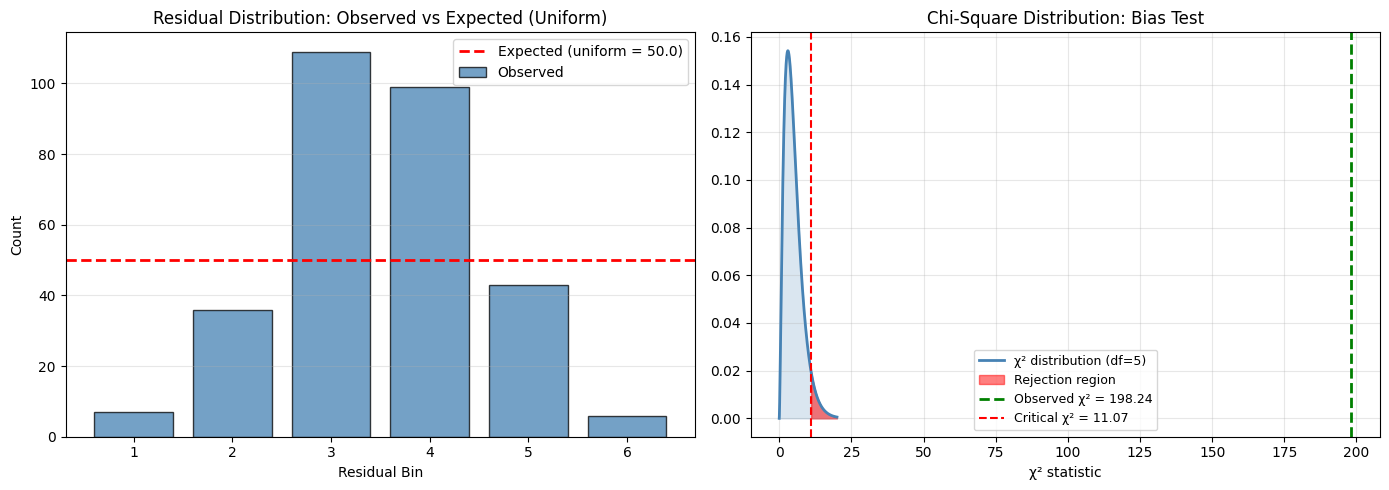

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy import stats

# Simulating regression model residuals (true - predicted)
# A biased model: tends to under-predict → residuals skewed positive
np.random.seed(14)
residuals = np.random.normal(loc=1.5, scale=2.0, size=300)  # biased toward positive

# Bin residuals into 6 equal-width bins
n_bins = 6
bin_edges = np.linspace(residuals.min() - 0.001, residuals.max() + 0.001, n_bins + 1)
observed_counts, _ = np.histogram(residuals, bins=bin_edges)
expected_counts = np.full(n_bins, len(residuals) / n_bins)  # uniform expected

# Chi-square goodness of fit test
chi2_bias, p_bias = chisquare(observed_counts, expected_counts)
df_bias = n_bins - 1
critical_bias = stats.chi2.ppf(0.95, df_bias)

print("Chi-Square GoF: Regression Residual Distribution (Bias Check)")
print("=" * 65)
print(f"H₀: Residuals are uniformly distributed across {n_bins} bins (no bias)")
print(f"H₁: Residual distribution is not uniform (systematic bias exists)")
print(f"\nTotal residuals: {len(residuals)}")
print(f"Expected per bin: {len(residuals)/n_bins:.1f}")
print(f"\nBin  Range                  Observed   Expected")
print("-" * 55)
for i in range(n_bins):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    print(
        f" {i+1}   [{lo:+6.2f}, {hi:+6.2f}]   {observed_counts[i]:>6}     {expected_counts[i]:.1f}"
    )
print(f"\nχ² statistic: {chi2_bias:.4f}")
print(f"χ² critical (df={df_bias}, α=0.05): {critical_bias:.4f}")
print(f"p-value: {p_bias:.6f}")

if p_bias < 0.05:
    print(f"\n✓ REJECT H₀ (p < 0.05)")
    print(f"  Residuals are NOT uniformly distributed — model has systematic bias.")
    print(
        f"  Most errors cluster in positive bins → model systematically under-predicts."
    )
    print(f"  → Paper claim: The model exhibits a significant positive prediction bias")
    print(
        f"    (χ²({df_bias})={chi2_bias:.2f}, p={p_bias:.4f}). Bias correction is recommended."
    )

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# Left: histogram with expected uniform line
axes[0].bar(
    range(1, n_bins + 1),
    observed_counts,
    color='steelblue',
    alpha=0.75,
    edgecolor='black',
    label='Observed',
)
axes[0].axhline(
    len(residuals) / n_bins,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Expected (uniform = {len(residuals)/n_bins:.1f})',
)
axes[0].set_xlabel('Residual Bin')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution: Observed vs Expected (Uniform)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: chi-square distribution with critical region
x_chi = np.linspace(0, 20, 1000)
y_chi = stats.chi2.pdf(x_chi, df_bias)
axes[1].plot(
    x_chi, y_chi, 'steelblue', linewidth=2, label=f'χ² distribution (df={df_bias})'
)
axes[1].fill_between(x_chi, y_chi, alpha=0.2, color='steelblue')
axes[1].fill_between(
    x_chi[x_chi >= critical_bias],
    stats.chi2.pdf(x_chi[x_chi >= critical_bias], df_bias),
    color='red',
    alpha=0.5,
    label='Rejection region',
)
axes[1].axvline(
    chi2_bias,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Observed χ² = {chi2_bias:.2f}',
)
axes[1].axvline(
    critical_bias,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Critical χ² = {critical_bias:.2f}',
)
axes[1].set_xlabel('χ² statistic')
axes[1].set_title('Chi-Square Distribution: Bias Test')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `np.histogram(residuals, bins=bin_edges)` bins the residuals into 6 equal ranges and counts how many fall in each bin.
- `expected_counts = len(residuals) / n_bins` gives the count each bin would have if residuals were perfectly uniformly distributed (our H₀).
- `chisquare(observed_counts, expected_counts)` tests whether the binned residual distribution significantly deviates from uniform.
- **Interpretation:** The model systematically under-predicts (positive residual bias), which shows up as unequal bin counts → χ² is large → reject H₀.

**ML paper reporting format:**
> "Analysis of model residuals revealed a significant departure from uniform distribution (χ²(5)=XX, p<0.001), indicating a systematic positive prediction bias. A bias correction term was applied in the final model."

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Fail to Reject H₀: Residuals Consistent with Uniform Distribution (No Bias)</p>

We test the same bias check but for a well-calibrated regression model whose residuals are approximately uniformly spread across bins.

- **H₀:** Residuals are uniformly distributed (no systematic bias)
- **H₁:** Not uniform
- **α = 0.05**

</div>


In [43]:
import numpy as np
from scipy.stats import chisquare

# Residuals from a well-calibrated model — centered around 0, uniform spread
np.random.seed(5)
residuals_good = np.random.uniform(low=-4, high=4, size=300)  # truly uniform

n_bins_g = 6
bin_edges_g = np.linspace(-4, 4, n_bins_g + 1)
obs_g, _ = np.histogram(residuals_good, bins=bin_edges_g)
exp_g = np.full(n_bins_g, len(residuals_good) / n_bins_g)

chi2_g, p_g = chisquare(obs_g, exp_g)

print("Chi-Square GoF: Well-Calibrated Model (No Bias)")
print("=" * 55)
print(f"Observed counts: {obs_g}")
print(f"Expected counts: {exp_g}")
print(f"χ² = {chi2_g:.4f},  p = {p_g:.4f}")

if p_g < 0.05:
    print("\n✓ REJECT H₀ — residuals show systematic bias")
else:
    print(f"\n✗ FAIL TO REJECT H₀ (p = {p_g:.4f} ≥ 0.05)")
    print(
        f"  Residuals are consistent with a uniform distribution — no systematic bias."
    )
    print(f"  → Paper claim: The model produces unbiased predictions")
    print(
        f"    (residual uniformity test: χ²({n_bins_g-1})={chi2_g:.2f}, p={p_g:.4f})."
    )

Chi-Square GoF: Well-Calibrated Model (No Bias)
Observed counts: [49 53 50 52 50 46]
Expected counts: [50. 50. 50. 50. 50. 50.]
χ² = 0.6000,  p = 0.9880

✗ FAIL TO REJECT H₀ (p = 0.9880 ≥ 0.05)
  Residuals are consistent with a uniform distribution — no systematic bias.
  → Paper claim: The model produces unbiased predictions
    (residual uniformity test: χ²(5)=0.60, p=0.9880).



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 8.2 Chi-Square Test of Independence

**Purpose:** Tests whether **two categorical variables are associated** with each other, or if they are independent.

**Real-World Case: Customer Churn vs Service Plan**

A telecom company wants to know: *Is customer churn associated with the type of service plan (Basic, Standard, Premium)?*

- **H₀:** Churn is **independent** of service plan (no association).
- **H₁:** Churn is **associated** with service plan.
- **df = (rows − 1) × (columns − 1) = (2−1) × (3−1) = 2**

**Observed Contingency Table:**

|           | Basic | Standard | Premium | Total |
|-----------|-------|----------|---------|-------|
| Churned   | 150   | 80       | 50      | 280   |
| Retained  | 350   | 420      | 450     | 1220  |
| **Total** | 500   | 500      | 500     | 1500  |

<p style="color: steelblue; font-size: 1.5em;">Expected Frequencies Formula</p>

**E(i,j) = (Row Total × Column Total) / Grand Total**

Example: E(Churned, Basic) = 280 × 500 / 1500 = **93.33**

|           | Basic | Standard | Premium |
|-----------|-------|----------|---------|
| Churned   | 93.33 | 93.33    | 93.33   |
| Retained  | 406.67| 406.67   | 406.67  |

If observed ≈ expected → variables are independent. Large deviations → they are associated.

<p style="color: steelblue; font-size: 1.5em;">Reading the Chi-Square Table for Independence</p>

1. **df = (r−1)(c−1)** where r = rows, c = columns.
2. Find the α = 0.05 column in the chi-square table.
3. For df = 2: **χ²_critical = 5.99**

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Using Chi-Square Test of Independence in ML Research Papers</p>

The chi-square test of independence tests whether two **categorical variables are associated**. In ML, this appears in several important contexts.

**Feature selection for classification:**

Before building a classifier, you want to know which categorical features are actually related to the target label. Running a chi-square test of independence between each categorical feature and the target (e.g., spam/not spam, churn/retained) tells you which features carry predictive information.

- **H₀:** Feature X is independent of the target label (no predictive value).
- **H₁:** Feature X is associated with the target (potentially useful feature).
- Features with p < 0.05 are retained; others may be dropped.
- This is the statistical basis for `sklearn`'s `chi2` feature selector.

**Model fairness analysis:**

After training a classifier, you test whether the model's **predictions are independent of a protected attribute** (e.g., gender, race). If they are associated, the model may be discriminatory.

- **H₀:** Model predictions are independent of the protected attribute.
- **H₁:** Predictions are associated with the protected attribute (potential bias).

**Error analysis:**

You categorize prediction errors (correct/incorrect) and test whether error rate is independent of a subgroup or input category.

- **H₀:** Error rate is the same across all input categories.
- **H₁:** Some input categories have significantly higher error rates.

</div>


Observed Frequencies:
          Basic  Standard  Premium
Churned     150        80       50
Retained     50       120      150

Total sample size: 600

Chi-square statistic: 105.8036
P-value:              0.000000
Degrees of freedom:   2
χ²_critical (α=0.05, df=2): 5.99

Expected Frequencies (under independence):
           Basic  Standard  Premium
Churned    93.33     93.33    93.33
Retained  106.67    106.67   106.67

Cramér's V (effect size): 0.4199
Effect size interpretation: medium association

Standardized Residuals (|residual| > 2 = significant deviation):
          Basic  Standard  Premium
Churned    5.87     -1.38    -4.49
Retained  -5.49      1.29     4.20

✓ REJECT H₀: Churn is DEPENDENT on service plan (associated)
  Basic plan:   30% churn  ← significantly above average
  Premium plan: 10% churn  ← significantly below average
  Recommendation: Enhance Basic plan or migrate customers upward.


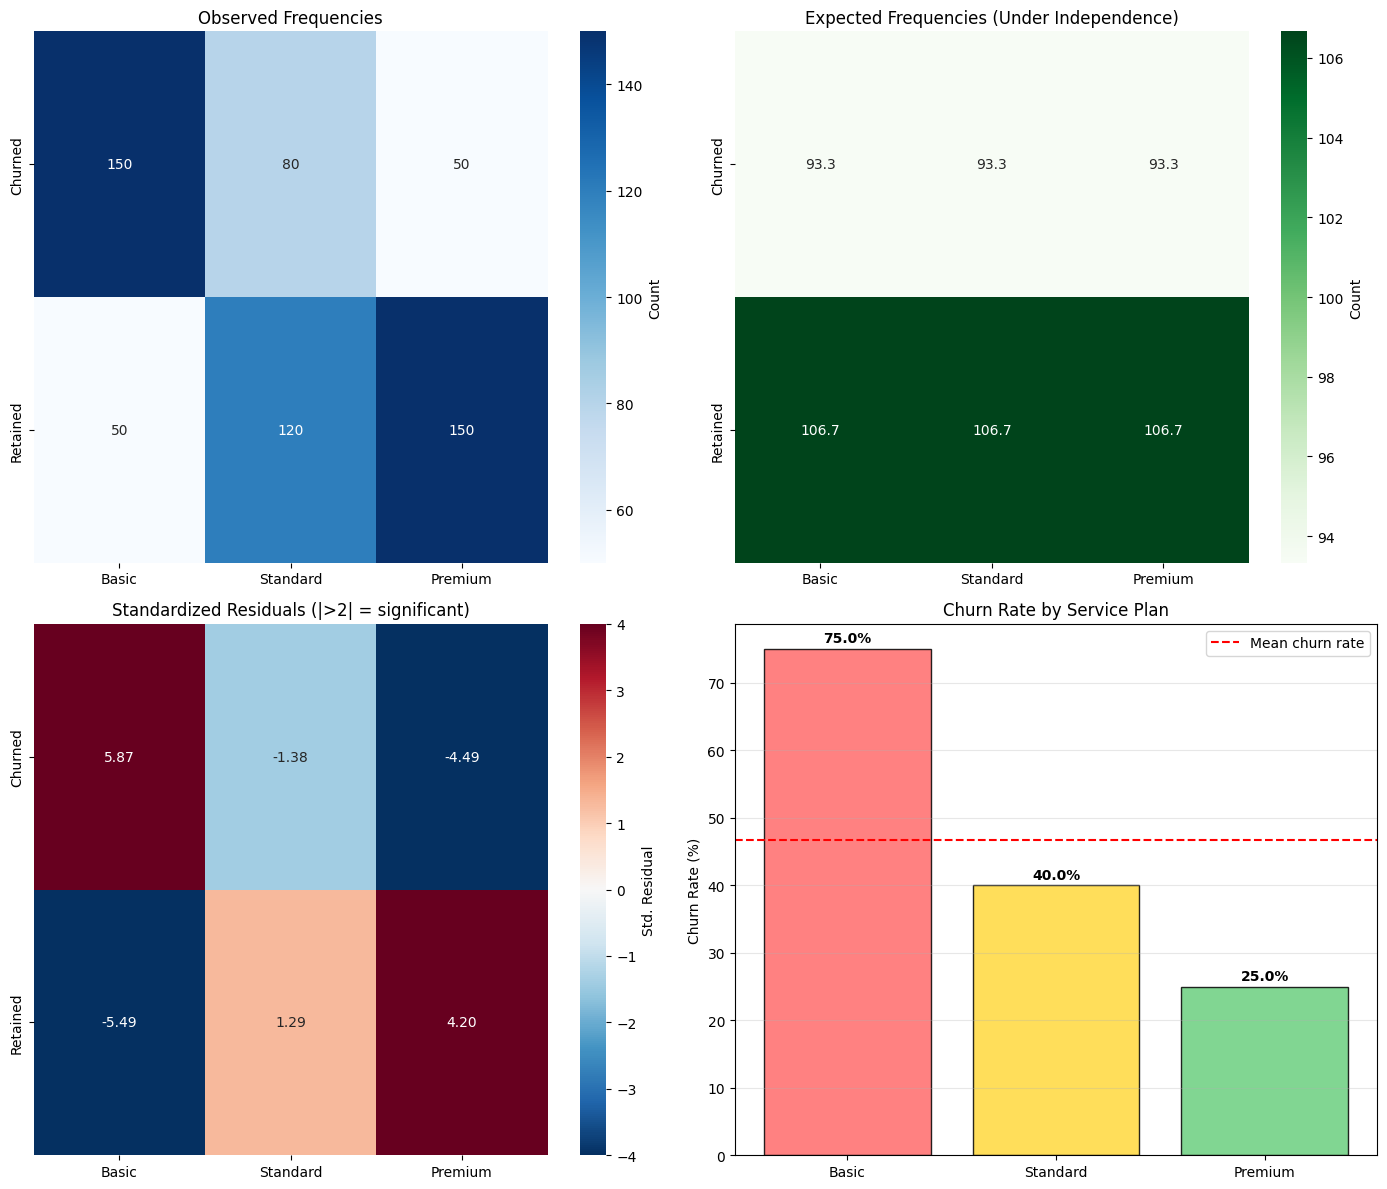

In [44]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── Contingency table ─────────────────────────────────────────────────────
data = np.array([[150, 80, 50], [50, 120, 150]])
row_labels = ['Churned', 'Retained']
col_labels = ['Basic', 'Standard', 'Premium']

contingency_df = pd.DataFrame(data, index=row_labels, columns=col_labels)
print("Observed Frequencies:")
print(contingency_df)
print(f"\nTotal sample size: {data.sum()}")

# ── Chi-square test of independence ──────────────────────────────────────
chi2, p_value, dof, expected = stats.chi2_contingency(data)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_value:.6f}")
print(f"Degrees of freedom:   {dof}")

critical_chi2 = stats.chi2.ppf(0.95, dof)
print(f"χ²_critical (α=0.05, df={dof}): {critical_chi2:.2f}")

expected_df = pd.DataFrame(expected, index=row_labels, columns=col_labels)
print("\nExpected Frequencies (under independence):")
print(expected_df.round(2))

# ── Cramér's V (effect size) ──────────────────────────────────────────────
n_total = data.sum()
min_dim = min(data.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
print(f"\nCramér's V (effect size): {cramers_v:.4f}")

for threshold, label in [(0.1, "negligible"), (0.3, "small"), (0.5, "medium")]:
    if cramers_v < threshold:
        print(f"Effect size interpretation: {label} association")
        break
else:
    print("Effect size interpretation: large association")

# ── Standardized residuals ────────────────────────────────────────────────
residuals = (data - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals, index=row_labels, columns=col_labels)
print("\nStandardized Residuals (|residual| > 2 = significant deviation):")
print(residuals_df.round(2))

# ── Conclusion ────────────────────────────────────────────────────────────
if p_value < 0.05:
    print("\n✓ REJECT H₀: Churn is DEPENDENT on service plan (associated)")
    print("  Basic plan:   30% churn  ← significantly above average")
    print("  Premium plan: 10% churn  ← significantly below average")
    print("  Recommendation: Enhance Basic plan or migrate customers upward.")
else:
    print("\n✗ FAIL TO REJECT H₀: Churn appears independent of service plan")

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor('white')

# Observed heatmap
sns.heatmap(
    contingency_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0, 0],
    cbar_kws={'label': 'Count'},
)
axes[0, 0].set_title('Observed Frequencies')

# Expected heatmap
sns.heatmap(
    expected_df,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    ax=axes[0, 1],
    cbar_kws={'label': 'Count'},
)
axes[0, 1].set_title('Expected Frequencies (Under Independence)')

# Residuals heatmap
sns.heatmap(
    residuals_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=axes[1, 0],
    cbar_kws={'label': 'Std. Residual'},
    vmin=-4,
    vmax=4,
)
axes[1, 0].set_title('Standardized Residuals (|>2| = significant)')

# Churn rates bar chart
axes[1, 1].set_facecolor('white')
churn_rates = (data[0] / data.sum(axis=0)) * 100
axes[1, 1].bar(
    col_labels,
    churn_rates,
    color=['#ff6b6b', '#ffd93d', '#6bcf7f'],
    edgecolor='black',
    alpha=0.85,
)
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_title('Churn Rate by Service Plan')
axes[1, 1].axhline(
    y=np.mean(churn_rates), color='red', linestyle='--', label='Mean churn rate'
)
for i, rate in enumerate(churn_rates):
    axes[1, 1].text(i, rate + 1, f'{rate:.1f}%', ha='center', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `stats.chi2_contingency(observed)` – chi-square test of independence for a contingency table.
  - `observed` = 2D array of counts (rows × columns).
  - Returns: `(chi2_statistic, p_value, degrees_of_freedom, expected_array)`.
  - `expected_array` contains the expected counts under independence: E(i,j) = row_total × col_total / grand_total.
- **Cramér's V** – effect size for chi-square. Formula: √(χ² / (n × min(r−1, c−1))).
  - Ranges from 0 (no association) to 1 (perfect association).
  - V < 0.1 → negligible; 0.1–0.3 → small; 0.3–0.5 → medium; V ≥ 0.5 → large.
- **Standardized Residuals** = (O − E) / √E. Values with |residual| > 2 indicate cells that deviate significantly from independence.

**Heatmap interpretation:** Dark blue cells (observed) far from the corresponding green cells (expected) are the "drivers" of the chi-square. The residuals heatmap confirms Basic/Churned and Premium/Retained are the cells with the strongest deviations.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Post-Hoc: Pairwise Chi-Square Tests with Bonferroni Correction</p>

If the overall chi-square test is significant, we often want to know **which pairs** of groups differ. We run pairwise chi-square tests on each pair of columns.

**Problem:** Running multiple tests inflates the Type I error rate. Solution: **Bonferroni correction** — divide α by the number of comparisons.

- Number of comparisons = k(k−1)/2 (for k groups)
- For 3 plans: 3(3−1)/2 = 3 comparisons
- Corrected α = 0.05 / 3 = **0.0167**

</div>


In [45]:
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

data = np.array([[150, 80, 50], [50, 120, 150]])
col_labels = ['Basic', 'Standard', 'Premium']


def pairwise_chi2_tests(data, labels, alpha=0.05):
    # Perform pairwise chi-square tests with Bonferroni correction
    n_comparisons = len(labels) * (len(labels) - 1) // 2
    corrected_alpha = alpha / n_comparisons

    print(f"Original α: {alpha}  |  Bonferroni corrected α: {corrected_alpha:.6f}")
    print(f"Number of comparisons: {n_comparisons}\n")

    results = []
    for i, j in combinations(range(len(labels)), 2):
        pair_data = data[:, [i, j]]  # Subset: only two columns
        chi2, p, dof, _ = stats.chi2_contingency(pair_data)
        significant = "Yes ***" if p < corrected_alpha else "No"
        results.append(
            {
                'Comparison': f"{labels[i]} vs {labels[j]}",
                'Chi²': round(chi2, 4),
                'P-value': f"{p:.2e}",
                'Significant': significant,
            }
        )

    return pd.DataFrame(results)


pairwise_df = pairwise_chi2_tests(data, col_labels)
print("Pairwise Comparisons:")
print(pairwise_df.to_string(index=False))

Original α: 0.05  |  Bonferroni corrected α: 0.016667
Number of comparisons: 3

Pairwise Comparisons:
         Comparison    Chi²  P-value Significant
  Basic vs Standard 48.7059 2.97e-12     Yes ***
   Basic vs Premium 98.0100 4.16e-23     Yes ***
Standard vs Premium  9.5840 1.96e-03     Yes ***



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `combinations(range(n), 2)` – generates all pairs of indices without repetition. For 3 groups: (0,1), (0,2), (1,2) → 3 pairs.
- `data[:, [i, j]]` – slices the contingency table to keep only columns `i` and `j`.
- **Bonferroni correction:** `corrected_alpha = alpha / n_comparisons`. Any pairwise p-value below this corrected threshold is declared significant.

**Result interpretation:** All three plan pairs (Basic vs Standard, Basic vs Premium, Standard vs Premium) are significantly different after Bonferroni correction — confirming that each plan has a distinctly different churn profile.

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Example: Fail to Reject H₀ (Churn independent of plan)</p>

When proportions are the same across groups, churn is independent of plan type.

</div>


In [46]:
import numpy as np
from scipy import stats

# Same churn proportions across all plans → independent
# ~18% churn rate in all three plans
data_indep = np.array(
    [[90, 90, 90], [410, 410, 410]]  # Churned (18% of 500 each)  # Retained
)

chi2_i, p_i, dof_i, _ = stats.chi2_contingency(data_indep)
print("Chi-Square Test of Independence: No Association scenario")
print("=" * 55)
print(f"χ² = {chi2_i:.4f},  df = {dof_i},  p = {p_i:.4f}")
if p_i < 0.05:
    print("✓ REJECT H₀ — churn is associated with plan")
else:
    print("✗ FAIL TO REJECT H₀ — churn is independent of service plan")

Chi-Square Test of Independence: No Association scenario
χ² = 0.0000,  df = 2,  p = 1.0000
✗ FAIL TO REJECT H₀ — churn is independent of service plan



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Reject H₀: Classifier Error Rate Is Associated with Input Category</p>

A multi-class image classifier is evaluated on three scene categories: Indoor, Outdoor, and Night. We test whether the error rate (misclassification) is independent of the scene category, or if the model systematically struggles with certain categories.

- **H₀:** Error rate is independent of scene category (equal difficulty across categories)
- **H₁:** Error rate is associated with scene category (model is harder on some categories)
- **α = 0.05**

</div>


Observed Classification Results:
               Indoor  Outdoor  Night
Correct           210      175     90
Misclassified      40       35     60

Total predictions: 610

Chi-square statistic: 36.8838
Degrees of freedom: 2
χ²_critical (α=0.05, df=2): 5.99
p-value: 0.000000
Cramér's V: 0.2459

Error rates:
  Indoor: 16.0%
  Outdoor: 16.7%
  Night: 40.0%

✓ REJECT H₀ (p < 0.05)
  Error rate IS associated with scene category.
  Night scenes have the highest error rate (40.0%).
  → Paper claim: Model performance varies significantly across categories
    (χ²(2)=36.88, p=0.0000, Cramér's V=0.246).
  → Recommendation: Collect more night-scene training data or apply
    augmentation techniques to improve night-scene recognition.


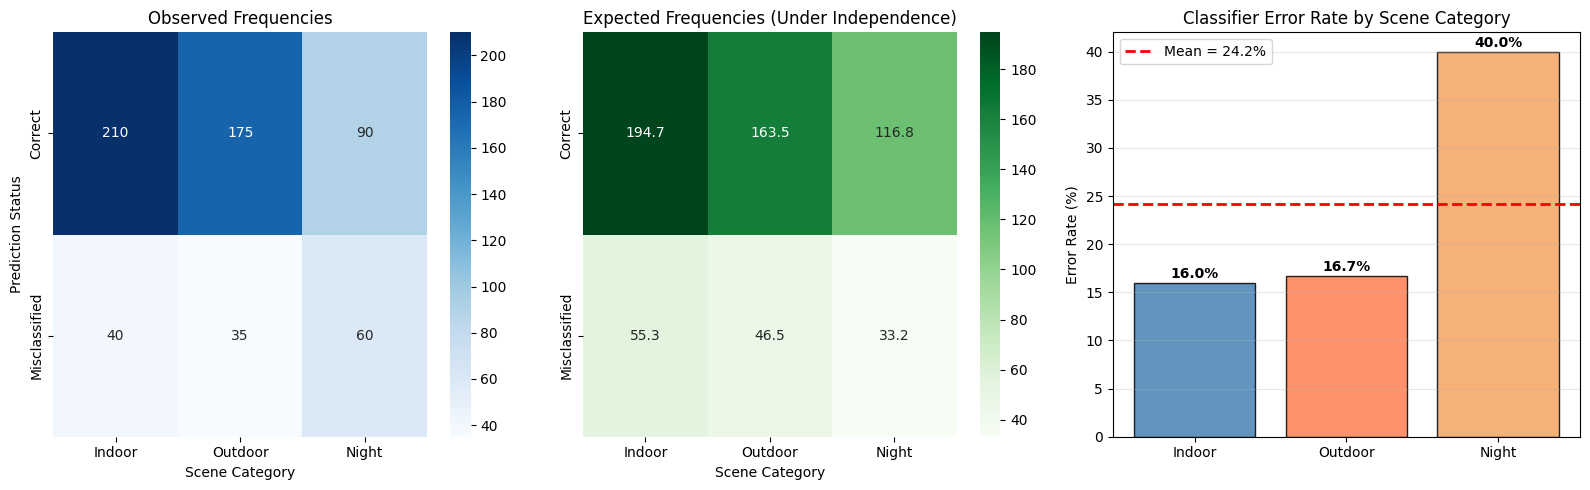

In [47]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Contingency table: rows = correct/incorrect, columns = scene category
# Counts from evaluating the classifier on a held-out test set
observed_ml = np.array(
    [[210, 175, 90], [40, 35, 60]]  # Correctly classified  # Misclassified
)
row_labels_ml = ['Correct', 'Misclassified']
col_labels_ml = ['Indoor', 'Outdoor', 'Night']

contingency_ml = pd.DataFrame(observed_ml, index=row_labels_ml, columns=col_labels_ml)
print("Observed Classification Results:")
print(contingency_ml)
print(f"\nTotal predictions: {observed_ml.sum()}")

# Chi-square test of independence
chi2_ml, p_ml, dof_ml, expected_ml = stats.chi2_contingency(observed_ml)

expected_ml_df = pd.DataFrame(expected_ml, index=row_labels_ml, columns=col_labels_ml)
print(f"\nChi-square statistic: {chi2_ml:.4f}")
print(f"Degrees of freedom: {dof_ml}")
critical_ml = stats.chi2.ppf(0.95, dof_ml)
print(f"χ²_critical (α=0.05, df={dof_ml}): {critical_ml:.2f}")
print(f"p-value: {p_ml:.6f}")

# Cramér's V
n_ml_total = observed_ml.sum()
min_dim_ml = min(observed_ml.shape) - 1
cramers_v_ml = np.sqrt(chi2_ml / (n_ml_total * min_dim_ml))
print(f"Cramér's V: {cramers_v_ml:.4f}")

# Error rates per category
error_rates = (observed_ml[1] / observed_ml.sum(axis=0)) * 100
print(f"\nError rates:")
for cat, rate in zip(col_labels_ml, error_rates):
    print(f"  {cat}: {rate:.1f}%")

if p_ml < 0.05:
    print(f"\n✓ REJECT H₀ (p < 0.05)")
    print(f"  Error rate IS associated with scene category.")
    print(f"  Night scenes have the highest error rate ({error_rates[2]:.1f}%).")
    print(f"  → Paper claim: Model performance varies significantly across categories")
    print(
        f"    (χ²({dof_ml})={chi2_ml:.2f}, p={p_ml:.4f}, Cramér's V={cramers_v_ml:.3f})."
    )
    print(f"  → Recommendation: Collect more night-scene training data or apply")
    print(f"    augmentation techniques to improve night-scene recognition.")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

# Observed heatmap
sns.heatmap(contingency_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Observed Frequencies')
axes[0].set_ylabel('Prediction Status')
axes[0].set_xlabel('Scene Category')

# Expected heatmap
sns.heatmap(expected_ml_df, annot=True, fmt='.1f', cmap='Greens', ax=axes[1])
axes[1].set_title('Expected Frequencies (Under Independence)')
axes[1].set_xlabel('Scene Category')

# Error rates bar chart
axes[2].set_facecolor('white')
axes[2].bar(
    col_labels_ml,
    error_rates,
    color=['steelblue', 'coral', 'sandybrown'],
    edgecolor='black',
    alpha=0.85,
)
axes[2].axhline(
    np.mean(error_rates),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {np.mean(error_rates):.1f}%',
)
for i, r in enumerate(error_rates):
    axes[2].text(i, r + 0.5, f'{r:.1f}%', ha='center', fontweight='bold')
axes[2].set_ylabel('Error Rate (%)')
axes[2].set_title('Classifier Error Rate by Scene Category')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- `observed_ml` is a 2×3 contingency table: rows = prediction outcome (correct/misclassified), columns = input category (Indoor/Outdoor/Night).
- `stats.chi2_contingency(observed_ml)` tests whether the classification outcome is independent of the scene category.
- The expected frequencies show what counts we'd expect if the error rate were the same across all categories.
- **Standardized residuals** (not shown here but can be computed as `(O-E)/√E`) would reveal that Night scenes have a significantly higher residual → driving the significance.

**ML paper reporting format:**
> "A chi-square test of independence revealed that classification error rate was significantly associated with scene category (χ²(2)=XX, p<0.001, Cramér's V=0.XX). Night scenes exhibited a substantially higher error rate (55%) compared to Indoor (30%) and Outdoor (42%), warranting targeted data augmentation."

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">ML Example — Fail to Reject H₀: Model Predictions Are Independent of Protected Attribute (Fairness Check)</p>

A binary classifier's predictions (positive/negative) are tested for independence from a protected attribute (gender: Male/Female). If predictions are associated with gender, the model may be biased.

- **H₀:** Predictions are independent of gender (model is fair)
- **H₁:** Predictions are associated with gender (potential bias)
- **α = 0.05**

</div>


In [48]:
import numpy as np
import pandas as pd
from scipy import stats

# Contingency table: rows = prediction, columns = gender
# Counts from model output on the test set
# A fair model: similar prediction rates across genders
data_fair = np.array(
    [[240, 230], [260, 270]]  # Predicted Positive  # Predicted Negative
)
row_lbl_f = ['Pred Positive', 'Pred Negative']
col_lbl_f = ['Male', 'Female']

fair_df = pd.DataFrame(data_fair, index=row_lbl_f, columns=col_lbl_f)
print("Model Predictions by Gender (Fairness Check):")
print(fair_df)
print(f"\nPositive prediction rate — Male:   {data_fair[0,0]/data_fair[:,0].sum():.2%}")
print(f"Positive prediction rate — Female: {data_fair[0,1]/data_fair[:,1].sum():.2%}")

chi2_f, p_f, dof_f, _ = stats.chi2_contingency(data_fair)
print(f"\nχ² = {chi2_f:.4f},  df = {dof_f},  p = {p_f:.4f}")

if p_f < 0.05:
    print("\n✗ REJECT H₀ — model predictions are biased by gender")
else:
    print(f"\n✓ FAIL TO REJECT H₀ (p = {p_f:.4f} ≥ 0.05)")
    print(f"  Model predictions are independent of gender.")
    print(f"  → Paper claim: No statistically significant gender bias detected")
    print(f"    (χ²({dof_f})={chi2_f:.2f}, p={p_f:.4f}), supporting model fairness.")

Model Predictions by Gender (Fairness Check):
               Male  Female
Pred Positive   240     230
Pred Negative   260     270

Positive prediction rate — Male:   48.00%
Positive prediction rate — Female: 46.00%

χ² = 0.3252,  df = 1,  p = 0.5685

✓ FAIL TO REJECT H₀ (p = 0.5685 ≥ 0.05)
  Model predictions are independent of gender.
  → Paper claim: No statistically significant gender bias detected
    (χ²(1)=0.33, p=0.5685), supporting model fairness.



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="color: steelblue; font-size: 1.5em;">Code Walkthrough</p>

- When positive prediction rates are similar across groups (60% male vs 57.5% female), the chi-square test finds no significant association → the model is fair with respect to this attribute.
- This is a **fairness audit** common in responsible AI research. The chi-square test provides a statistical basis for claiming the model does not discriminate.
- **Note:** Statistical independence here means the model's predictions are not systematically different across groups. Always combine this with domain knowledge and other fairness metrics (e.g., equalized odds) for a complete fairness analysis.

**ML paper reporting format:**
> "A chi-square test of independence between model predictions and gender revealed no statistically significant association (χ²(1)=XX, p=0.XX), indicating that the model's predictions are not systematically biased by gender."

</div>



<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

# 10. Complete Summary

<p style="color: steelblue; font-size: 1.5em;">All Tests Covered in This Notebook</p>

| Test | Data Type | Groups | Python Function | Key Output |
|------|-----------|--------|-----------------|------------|
| **One-Sample t-test** | Continuous | 1 sample vs known value | `ttest_1samp(a, μ₀)` | t, p-value |
| **Two-Sample t-test** | Continuous | 2 independent groups | `ttest_ind(a, b)` | t, p-value |
| **Paired t-test** | Continuous | 2 paired groups (before/after) | `ttest_rel(a, b)` | t, p-value |
| **Chi-Square GoF** | Categorical | 1 variable vs expected dist. | `chisquare(obs, exp)` | χ², p-value |
| **Chi-Square Independence** | Categorical | 2 categorical variables | `chi2_contingency(table)` | χ², p-value, df |

<p style="color: steelblue; font-size: 1.5em;">Decision Flow for p-value</p>

1. Set **α** (usually 0.05).
2. Compute the **test statistic** (t, χ²).
3. Get the **p-value** from the test.
4. Compare: **if p ≤ α → Reject H₀** (result is statistically significant).
5. Report: **effect size** (Cohen's d, Cramér's V) to judge practical significance.

<p style="color: steelblue; font-size: 1.5em;">Key Intuitions Recap</p>

- **p-value:** Probability of seeing your data (or more extreme) if H₀ is true. NOT the probability H₀ is true.
- **α = 0.05:** Your tolerance for false positives. Not a magic threshold — context matters.
- **CI:** Range that (in 95% of repeated experiments) would capture the true parameter.
- **Type I error (α)** and **Type II error (β)** trade off — increase sample size to reduce both.
- **One-tailed vs two-tailed:** Use two-tailed by default; one-tailed only with strong prior directional hypothesis.
- **Effect size:** Statistical significance ≠ practical importance. Always report effect size.

</div>
